# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

**INTRODUCCIÓN**

Para determinar cuál tarifa genera más ingresos para Megaline, es fundamental comenzar con un análisis exploratorio exhaustivo de los datos disponibles. Este proceso nos permitirá comprender la estructura, calidad y características de la información antes de proceder con el análisis estadístico y las pruebas de hipótesis.

El dataset está compuesto por cinco tablas interrelacionadas que contienen información sobre usuarios, patrones de uso (llamadas, mensajes, internet) y características de las tarifas. Cada tabla requiere una evaluación detallada para identificar posibles inconsistencias, valores faltantes o transformaciones necesarias que puedan impactar nuestro análisis posterior.

Esta exploración inicial establecerá las bases sólidas necesarias para realizar comparaciones precisas entre las tarifas Surf y Ultimate, asegurando que nuestras conclusiones sobre rentabilidad estén respaldadas por datos confiables y correctamente procesados.

## Inicialización

In [1]:
# Cargar todas las librerías

# Manipulación de datos
import pandas as pd #manipulación de datos
import numpy as np #operaciones númericas

# Visualización
import matplotlib.pyplot as plt # gráficos básicas
import seaborn as sns # gráficos estadísticos avanzados

# Análisis estadístico
from scipy import stats as st # pruebas de hipótesis


## Cargar datos

In [76]:
# Carga los archivos de datos en diferentes DataFrames

users = pd.read_csv('/datasets/megaline_users.csv') # datos sobre los usuarios
calls = pd.read_csv('/datasets/megaline_calls.csv') # datos sobre las llamadas
messages = pd.read_csv('/datasets/megaline_messages.csv') # datos sobre los SMS 
internet = pd.read_csv('/datasets/megaline_internet.csv') # datos sobre las sesiones web
plans = pd.read_csv('/datasets/megaline_plans.csv') # datos sobre las tarifas



In [77]:
# Verificación que los datos se cargaron correctamente y la cantidad de registros en cada archivo

print("Datos cargados exitosamente:")
print(f"- Usuarios: {users.shape[0]} registros")
print(f"- Llamadas: {calls.shape[0]} registros")
print(f"- Mensajes: {messages.shape[0]} registros")
print(f"- Internet: {internet.shape[0]} registros")
print(f"- Planes: {plans.shape[0]} registros")


Datos cargados exitosamente:
- Usuarios: 500 registros
- Llamadas: 137735 registros
- Mensajes: 76051 registros
- Internet: 104825 registros
- Planes: 2 registros


## Preparar los datos

En esta sección realizaremos una exploración sistemática de cada tabla del dataset para comprender la estructura y calidad de los datos disponibles. Para cada tabla aplicaremos las siguientes técnicas de análisis exploratorio:

- **`.info()`**: Para examinar la estructura general de cada tabla, incluyendo tipos de datos, valores nulos y memoria utilizada
- **`.sample()`**: Para obtener una muestra aleatoria de registros que nos permita visualizar ejemplos reales de los datos

Esta exploración inicial nos permitirá identificar posibles problemas en los datos (valores faltantes, tipos incorrectos, inconsistencias) y planificar las transformaciones necesarias antes del análisis principal.

In [78]:
users.info() # Información general de usuarios

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [79]:
users.sample(5) # Muestra aleatoria de usuarios

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
170,1170,Olin,Adkins,18,"Pittsburgh, PA MSA",2018-09-25,surf,NaN
225,1225,Margarito,Barker,41,"Columbia, SC MSA",2018-06-07,surf,NaN
404,1404,Paulita,Conley,33,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-16,surf,NaN
161,1161,Florance,Estrada,52,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-27,ultimate,NaN
302,1302,Leonila,Morris,62,"Rochester, NY MSA",2018-01-21,surf,NaN


**Observaciones de la tabla users:**

- Estructura: Se confirman 500 registros de usuarios, coincidiendo con lo especificado en el proyecto.

- Tipos de datos: La columna reg_date está almacenada como objeto (string) en lugar de formato datetime, lo cual requerirá conversión posterior.

- Valores faltantes: La columna churn_date presenta 34 valores nulos (466 valores ausentes), lo que indica que estos usuarios permanecían activos al momento de la extracción de datos.

In [80]:
calls.info() # Información general de llamadas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [81]:
calls.sample(5) # Muestra aleatoria de llamadas

,id,user_id,call_date,duration
49588,1179_247,1179,2018-09-05,0.00
104628,1368_334,1368,2018-10-26,4.83
13661,1058_87,1058,2018-12-04,7.81
4804,1022_70,1022,2018-10-30,15.81
93659,1334_1027,1334,2018-05-15,2.66


**Observaciones de la tabla calls:**

- Estructura: Se cuenta con 137.735 registros de llamadas. El patrón de id sugiere formato user_id_secuencia (ej: 1314_35).
- Tipos de datos:  La columna call_date requiere conversión a datetime. Duration presenta valores decimales que necesitarán redondeo según políticas de Megaline. Se observan valores de 0.00 minutos que podrían indicar llamadas fallidas, desconexiones inmediatas o intentos de conexión sin establecimiento exitoso, aspecto a considerar en el análisis posterior.
- Valores faltantes: No se detectan valores ausentes en ninguna columna


In [82]:
messages.info() # Información general de mensajes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [83]:
messages.sample(5) # Muestra aleatoria de mensajes

,id,user_id,message_date
17356,1114_215,1114,2018-12-09
22430,1133_581,1133,2018-11-17
21345,1132_646,1132,2018-06-18
65438,1421_23,1421,2018-11-30
38121,1251_173,1251,2018-08-16


**Observaciones de la tabla messages:**

- Estructura: Se tienen 76.051 registros de mensajes. Los IDs siguen el patrón user_id_secuencia (ej: 1355_257, 1203_33), sugiriendo identificadores secuenciales por usuario.
- Tipos de datos: La columna message_date requiere conversión a formato datetime. 
- Valores faltantes: No se detectan valores ausentes en ninguna columna.

In [84]:
internet.info() # Información general de sesiones web 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [85]:
internet.sample(5) # Muestra aleatoria de sesiones web

,id,user_id,session_date,mb_used
93978,1439_31,1439,2018-06-13,263.85
3364,1018_337,1018,2018-10-23,422.39
35078,1157_165,1157,2018-09-28,607.79
69527,1324_245,1324,2018-04-07,181.67
82078,1384_310,1384,2018-09-02,835.75


**Observaciones de la tabla internet:**

- Estructura: Se registran 104.825 sesiones web con IDs que siguen el patrón user_id_secuencia (ej: 1312_507, 1440_52). Se evidencia la misma estructura de identificación secuencial observada en otras tablas.
- Tipos de datos: La columna session_date requiere conversión a formato datetime. La columna mb_used está en megabytes, pero Megaline redondea a gigabytes para facturación. Se observan valores de 0.00 MB que podrían indicar errores de conexión o sesiones fallidas, aspecto a considerar en el análisis posterior.
- Valores faltantes: No se detectan valores ausentes en ninguna columna.

**Nota general**: Los valores de 0.00 observados en las tablas de uso (calls, internet) sugieren un patrón común de registros de actividad sin consumo efectivo, posiblemente debido a fallas técnicas o intentos de conexión no exitosos. Se revisará su relevancia según los objetivos específicos del análisis.

In [86]:
plans.info() # Información general de tarifas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [87]:
plans.sample(2) # Muestra aleatoria de tarifas. Solo aplica 2 registros para esta tabla

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate
0,50,15360,500,20,10,0.03,0.03,surf


**Observaciones de la tabla plans:**

- Estructura: Se confirman 2 registros correspondientes a las tarifas Surf y Ultimate de Megaline. La tabla contiene 8 columnas que definen las características y costos de cada plan.
- Tipos de datos: Los datos están correctamente tipificados: valores enteros para límites incluidos y pagos mensuales (int64), valores decimales para tarifas por exceso (float64), y texto para nombres de planes (object). No se requieren conversiones adicionales.
- Valores faltantes: No se detectan valores ausentes en ninguna columna. Todos los campos están completos para ambas tarifas.


## Tarifas

In [88]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [89]:
# Imprime una muestra de los datos para las tarifas
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Los tipos de datos son correctos de acuerdo con la información disponible. Además, como ya habíamos mencionado, no se identificaron datos ausentes en las tablas analizadas. 

Sin embargo, es importante destacar que será necesario realizar una corrección de datos en la tabla internet: convertir la columna mb_used (megabytes) a gigabytes para facilitar los cálculos posteriores de facturación. Según las especificaciones del proyecto, las sesiones web individuales no se redondean; en su lugar, el total mensual de megabytes se redondea hacia arriba al gigabyte más cercano para efectos de cobro.

## Corregir datos

**Estandarización de unidades en la tabla plans:**
Se requiere convertir los megabytes incluidos por mes a gigabytes para mantener coherencia con las unidades utilizadas en el análisis de consumo de internet y facilitar los cálculos de facturación.

In [90]:
# Convertir MB a GB en la tabla plans
plans['gb_per_month_included'] = plans['mb_per_month_included'] / 1024
plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


## Enriquecer los datos

En este caso no considero necesario agregar factores adicionales puesto que ya se tiene la información para poder calcular:
- Excesos por servicio de los usuarios
- Costos adicionales
- Comparar rentabilidad entre los planes de acuerdo al consumo de los usuarios

In [91]:
# No se necesita enriquecimiento adicional
# La tabla plans ya contiene toda la información necesaria para el análisis

## Usuarios/as

In [92]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [93]:
# Imprime una muestra de datos para usuarios
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [94]:
# Verificar si hay filas completamente duplicadas
print("Filas duplicadas: ", users.duplicated().sum())  # Cuenta cuántas filas duplicadas hay

Filas duplicadas:  0


In [95]:
# Ver si hay columnas con nombres duplicados
print("Columnas duplicadas: ",users.columns.duplicated().sum()) # Cuenta cuántas columnas duplicadas hay

Columnas duplicadas:  0


In [96]:
# Verificar distribución de usuarios por plan en la tabla users
plan_distribution = users['plan'].value_counts()
print("Distribución total de usuarios por plan:")
print(plan_distribution)
print(f"\nPorcentajes:")
print(users['plan'].value_counts(normalize=True) * 100)

Distribución total de usuarios por plan:
surf        339
ultimate    161
Name: plan, dtype: int64

Porcentajes:
surf        67.8
ultimate    32.2
Name: plan, dtype: float64


**Análisis de los datos de la tabla users**

No se detectaron filas ni columnas duplicadas, confirmando la integridad de los datos.

La columna reg_date está almacenada como objeto (string) en lugar de formato datetime, requiriendo conversión para análisis.

La columna churn_date presenta 466 valores nulos (solo 34 usuarios tienen fecha de cancelación), indicando que 93.2% de los usuarios permanecían activos al momento de la extracción.

**Distribución de Usuarios por Plan**

La base de usuarios de Megaline muestra una distribución desigual entre los dos planes ofrecidos:
- Plan Surf: 339 usuarios (67.8% del total)
- Plan Ultimate: 161 usuarios (32.2% del total)

El plan Surf tiene más del doble de usuarios que el plan Ultimate, representando aproximadamente 2 de cada 3 clientes. Esta distribución sugiere que la mayoría de los usuarios prefieren el plan básico, posiblemente por su menor costo mensual, lo que será un factor clave a considerar en el análisis de rentabilidad posterior.

### Corregir los datos

**Conversión de tipos de datos en la tabla users:** Se requiere convertir la columna reg_date de formato objeto (string) a datetime para habilitar el análisis temporal de patrones de registro y facilitar los cálculos de duración de permanencia de usuarios en el servicio.

In [97]:
# Convertir reg_date a formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [98]:
users.info() #Verificar conversión

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


### Enriquecer los datos

**Creación de variables adicionales en la tabla users:** Se requiere agregar una columna de estado del usuario (activo/cancelado) para facilitar la segmentación y extraer componentes temporales (año, mes) de la fecha de registro para habilitar el análisis de patrones de comportamiento por períodos específicos. No se incluye el día ya que el análisis se enfoca en métricas mensuales agregadas, alineándose con el modelo de facturación mensual de las tarifas Megaline.

In [99]:
# Crear columna de estado del usuario
users['is_active'] = users['churn_date'].isna()

In [100]:
# Extraer información temporal de reg_date
users['reg_year'] = users['reg_date'].dt.year
users['reg_month'] = users['reg_date'].dt.month

In [101]:
users.sample(5) #Verificar creación de variables adicionales

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_active,reg_year,reg_month
404,1404,Paulita,Conley,33,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-16,surf,NaN,True,2018,4
135,1135,Scotty,White,51,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-12-23,ultimate,NaN,True,2018,12
202,1202,Osvaldo,Mayer,36,"Minneapolis-St. Paul-Bloomington, MN-WI MSA",2018-09-30,ultimate,NaN,True,2018,9
65,1065,Sherlyn,Noel,26,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-08-03,surf,NaN,True,2018,8
413,1413,Andre,Hensley,38,"Bakersfield, CA MSA",2018-07-12,surf,NaN,True,2018,7


## Llamadas

In [102]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [103]:
# Imprime una muestra de datos para las llamadas
calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [104]:
# Verificar si hay filas completamente duplicadas
print("Filas duplicadas: ", calls.duplicated().sum())  # Cuenta cuántas filas duplicadas hay

Filas duplicadas:  0


In [105]:
# Ver si hay columnas con nombres duplicados
print("Columnas duplicadas: ",calls.columns.duplicated().sum()) # Cuenta cuántas columnas duplicadas hay

Columnas duplicadas:  0


In [106]:
# Unir los datos de llamadas con los datos de usuarios para obtener el plan
calls_with_plan = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Verificar distribución de llamadas por plan
plan_calls_distribution = calls_with_plan['plan'].value_counts()
print("Distribución total de llamadas por plan:")
print(plan_calls_distribution)
print(f"\nPorcentajes:")
print(calls_with_plan['plan'].value_counts(normalize=True) * 100)

Distribución total de llamadas por plan:
surf        94084
ultimate    43651
Name: plan, dtype: int64

Porcentajes:
surf        68.307983
ultimate    31.692017
Name: plan, dtype: float64


**Análisis de los datos de la tabla calls**

No se detectaron filas ni columnas duplicadas, confirmando la integridad de los datos.

La columna call_date está almacenada como objeto (string) en lugar de formato datetime, requiriendo conversión para análisis.

La columna duration presenta valores decimales que necesitarán redondeo según políticas de Megaline. Se observan valores de 0.00 minutos que podrían indicar llamadas fallidas, desconexiones inmediatas o intentos de conexión sin establecimiento exitoso, aspecto a considerar en el análisis.


**Distribución de Llamadas por Plan**

El análisis del volumen total de llamadas realizadas por los usuarios de Megaline revela una distribución que refleja directamente la composición de la base de usuarios:

- Plan Surf: 94,084 llamadas (68.3% del total)
- Plan Ultimate: 43,651 llamadas (31.7% del total)

La distribución de llamadas mantiene una proporción muy similar a la distribución de usuarios por plan (67.8% Surf vs 32.2% Ultimate), lo que sugiere un comportamiento de llamadas relativamente homogéneo entre ambas tarifas. Los usuarios del plan Surf generan aproximadamente 2.2 veces más llamadas en volumen total que los usuarios Ultimate, principalmente debido a que representan más del doble de la base de usuarios.

### Corregir los datos

**Conversión de tipos de datos en la tabla calls:** Se requiere convertir la columna call_date de formato objeto (string) a datetime para habilitar el análisis temporal de patrones de llamadas y facilitar los cálculos de facturación mensual. Adicionalmente, los valores decimales en duration necesitan redondeo según las políticas de facturación de Megaline para garantizar la precisión en el cálculo de costos por minutos excedentes. También se realizará un análisis específico de los registros con duración de 0.00 minutos para evaluar su representatividad en el conjunto de datos y determinar su impacto en los cálculos de facturación.

In [107]:
# Convertir reg_date a formato datetime
calls['call_date'] = pd.to_datetime(calls['call_date'])

In [108]:
calls.info() #Verificar conversión

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [109]:
# Aplicar redondeo hacia arriba según políticas de Megaline

# Las llamadas de 0.00 minutos permanecen como 0, las demás se redondean hacia arriba
calls['duration_rounded'] = np.where(
    calls['duration'] == 0.00,  # Si la duración es exactamente 0.00
    0.00,                       # Mantener como 0.00
    np.ceil(calls['duration'])  # Caso contrario, redondear hacia arriba
)

In [110]:
calls.sample(5) #Verificar redondeo hacia arriba según políticas de Megaline

,id,user_id,call_date,duration,duration_rounded
41313,1152_270,1152,2018-11-07,12.57,13.0
127103,1454_93,1454,2018-11-28,0.00,0.0
5437,1026_215,1026,2018-08-15,10.98,11.0
129050,1465_247,1465,2018-07-16,8.60,9.0
126708,1451_108,1451,2018-09-05,10.98,11.0


**Análisis de las llamadas de 0.00 minutos**

Dado que se han identificado valores de 0.00 minutos en los datos de llamadas, se realizará un análisis específico para determinar qué tan representativos son estos registros en el conjunto de datos y evaluar su impacto en el análisis general.

In [111]:
# Analizar los valores de 0.00 minutos
zero_duration_calls = calls[calls['duration'] == 0.00]
print(f"Llamadas con 0.00 minutos: {len(zero_duration_calls)}")
print(f"Porcentaje del total: {len(zero_duration_calls)/len(calls)*100:.2f}%")

Llamadas con 0.00 minutos: 26834
Porcentaje del total: 19.48%


In [112]:
# Unir los datos de llamadas con los datos de usuarios para tener la información de la tarifa
calls_with_plan = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Analizar las llamadas de 0.00 minutos por tarifa
zero_calls_analysis = calls_with_plan.groupby('plan').agg({
    'duration': ['count', lambda x: (x == 0.00).sum()]
}).round(2)

# Renombrar las columnas para mayor claridad
zero_calls_analysis.columns = ['total_calls', 'zero_duration_calls']
zero_calls_analysis['percentage_zero'] = (zero_calls_analysis['zero_duration_calls'] / 
                                         zero_calls_analysis['total_calls'] * 100).round(2)

print(f"\nDistribución de llamadas con 0.00 minutos por tarifa:")
print()
print(zero_calls_analysis)


Distribución de llamadas con 0.00 minutos por tarifa:

          total_calls  zero_duration_calls  percentage_zero
plan                                                       
surf            94084              18207.0            19.35
ultimate        43651               8627.0            19.76


In [113]:
# Unir datos de llamadas con usuarios para obtener el plan
calls_with_plan = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Obtener usuarios que tienen al menos una llamada de 0.00 minutos
users_with_zero_calls = calls_with_plan[calls_with_plan['duration'] == 0.00]['user_id'].unique()

print(f"Usuarios con llamadas de 0.00 minutos: {len(users_with_zero_calls)}")

Usuarios con llamadas de 0.00 minutos: 478


In [114]:
# Crear tabla equivalente a user_zero_internet pero para llamadas
calls_with_plan = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

user_zero_calls = calls_with_plan.groupby(['user_id', 'plan']).agg({
    'duration': ['count', lambda x: (x == 0.00).sum()]
}).round(2)

# Aplanar las columnas
user_zero_calls.columns = ['total_calls', 'zero_duration_calls']
user_zero_calls = user_zero_calls.reset_index()

# Calcular porcentaje de llamadas con 0.00 minutos por usuario
user_zero_calls['zero_percentage'] = (user_zero_calls['zero_duration_calls'] / 
                                     user_zero_calls['total_calls'] * 100).round(2)

# Ahora sí puedes contar usuarios que NO tienen llamadas de 0.00 minutos
users_without_zero_calls = user_zero_calls[user_zero_calls['zero_percentage'] == 0.0]

print("Usuarios SIN llamadas de 0.00 minutos:")
print(f"Surf: {len(users_without_zero_calls[users_without_zero_calls['plan'] == 'surf'])}")
print(f"Ultimate: {len(users_without_zero_calls[users_without_zero_calls['plan'] == 'ultimate'])}")
print(f"Total: {len(users_without_zero_calls)}")

Usuarios SIN llamadas de 0.00 minutos:
Surf: 2
Ultimate: 1
Total: 3


In [115]:
#Teniendo en cuenta que se tienen 478 usuarios con llamadas y 3 sin llamadas de 0,00
#Verificar usuarios sin registros de llamadas en la tabla de calls

# Obtener todos los user_id de la tabla users
all_users = set(users['user_id'])

# Obtener todos los user_id que aparecen en la tabla calls
users_with_calls = set(calls['user_id'])

# Encontrar usuarios que NO tienen registros de llamadas
users_without_calls = all_users - users_with_calls

print(f"Usuarios sin registros de llamadas: {len(users_without_calls)}")
print(f"IDs de usuarios sin llamadas: {sorted(list(users_without_calls))}")

Usuarios sin registros de llamadas: 19
IDs de usuarios sin llamadas: [1025, 1080, 1089, 1108, 1121, 1129, 1131, 1137, 1143, 1194, 1204, 1269, 1275, 1307, 1319, 1349, 1378, 1463, 1473]


**Conclusión de análisis de las llamadas de 0.00 minutos**

Basados en los resultados obtenidos, se tiene los siguientes datos clave:

- 26,834 llamadas con duración de 0.00 minutos (19.48% del total)
- Distribución por plan: Surf 19.35% vs Ultimate 19.76% (prácticamente idéntica)
- 478 de 500 usuarios tienen al menos una llamada de 0.00 minutos
- 3 usuarios (2 de Surf y 1 de Ultimate) registrados en las llamadas no tienen registro de llamadas de 0.00 minutos
- 19 de 500 usuarios no registran llamadas realizadas

Las llamadas de 0.00 minutos, podrían representar:
- Llamadas técnicamente válidas: Intentos de conexión que se registran pero no se establecen exitosamente
- Llamadas perdidas: El receptor no contesta pero se genera un registro
- Errores de red: Desconexiones inmediatas por problemas técnicos
- Llamadas de verificación: Pruebas del sistema o verificaciones automáticas

Para nuestro análisis se van a mantener dentro de los datos las llamadas de 0.00 minutos por las siguientes razones:

- Universalidad del patrón: 99.4% de usuarios las tienen, sugiriendo que es parte normal del comportamiento
- Distribución equilibrada: Ambos planes muestran porcentajes similares (~19.4%), no hay sesgo
- Realidad operativa: Representan intentos reales de uso del servicio
- Impacto en facturación: Aunque no generan costo por minutos, sí consumen recursos de red


### Enriquecer los datos

**Creación de variables adicionales en la tabla calls:** Se requiere extraer componentes temporales (año, mes) de la fecha de llamada para habilitar el análisis de patrones de uso por períodos específicos y facilitar la agregación mensual de datos para el cálculo de facturación. 

In [116]:
# Extraer información temporal de call_date
calls['call_year'] = calls['call_date'].dt.year
calls['call_month'] = calls['call_date'].dt.month

In [117]:
calls.sample(5) #Verificar creación de variables adicionales

,id,user_id,call_date,duration,duration_rounded,call_year,call_month
69657,1249_609,1249,2018-08-24,10.36,11.0,2018,8
72115,1256_400,1256,2018-11-16,12.91,13.0,2018,11
22183,1082_134,1082,2018-07-29,3.55,4.0,2018,7
120492,1420_62,1420,2018-08-22,7.11,8.0,2018,8
135077,1490_177,1490,2018-12-15,13.45,14.0,2018,12


## Mensajes

In [118]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [119]:
# Imprime una muestra de datos para los mensajes
messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [120]:
# Verificar si hay filas completamente duplicadas
print("Filas duplicadas: ", messages.duplicated().sum())  # Cuenta cuántas filas duplicadas hay

Filas duplicadas:  0


In [121]:
# Ver si hay columnas con nombres duplicados
print("Columnas duplicadas: ",messages.columns.duplicated().sum()) # Cuenta cuántas columnas duplicadas hay

Columnas duplicadas:  0


In [122]:
# Unir los datos de mensajes con los datos de usuarios para obtener el plan
messages_with_plan = messages.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Verificar distribución de llamadas por plan
plan_messages_distribution = messages_with_plan['plan'].value_counts()
print("Distribución total de mensajes por plan:")
print(plan_messages_distribution)
print(f"\nPorcentajes:")
print(messages_with_plan['plan'].value_counts(normalize=True) * 100)

Distribución total de mensajes por plan:
surf        49014
ultimate    27037
Name: plan, dtype: int64

Porcentajes:
surf        64.448857
ultimate    35.551143
Name: plan, dtype: float64


**Análisis de los datos de la tabla messages**

No se detectaron filas ni columnas duplicadas, confirmando la integridad de los datos.

La columna message_date requiere conversión a formato datetime. 


**Distribución de Mensajes por Plan**

El análisis del volumen total de mensajes enviados por los usuarios de Megaline muestra una distribución que mantiene consistencia con el patrón observado en las llamadas y la composición de la base de usuarios:

Plan Surf: 49,014 mensajes (64.4% del total)
Plan Ultimate: 27,837 mensajes (35.6% del total)
La distribución de mensajes presenta una proporción ligeramente diferente comparada con la distribución de usuarios por plan (67.8% Surf vs 32.2% Ultimate) y las llamadas (68.3% Surf vs 31.7% Ultimate). Los usuarios del plan Surf generan aproximadamente 1.8 veces más mensajes en volumen total que los usuarios Ultimate.

Esta variación sugiere que los usuarios del plan Ultimate tienen un comportamiento ligeramente más activo en el envío de mensajes en relación a su proporción en la base de usuarios, lo que podría indicar un perfil de uso más intensivo de servicios de mensajería entre los suscriptores de la tarifa premium.


### Corregir los datos

**Conversión de tipos de datos en la tabla messages:** Se requiere convertir la columna message_date de formato objeto (string) a datetime para habilitar el análisis temporal de patrones de mensajes y facilitar los cálculos de facturación mensual. 

In [123]:
# Convertir message_date a formato datetime
messages['message_date'] = pd.to_datetime(messages['message_date'])

In [124]:
messages.info() #Verificar conversión

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

**Creación de variables adicionales en la tabla messages:** Se requiere extraer componentes temporales (año, mes) de la fecha de mensaje para habilitar el análisis de patrones de uso por períodos específicos y facilitar la agregación mensual de datos para el cálculo de facturación.

In [125]:
# Extraer información temporal de message_date
messages['message_year'] = messages['message_date'].dt.year
messages['message_month'] = messages['message_date'].dt.month

In [126]:
messages.sample(5) #Verificar creación de variables adicionales

,id,user_id,message_date,message_year,message_month
11974,1079_373,1079,2018-09-01,2018,9
72659,1470_287,1470,2018-07-05,2018,7
47048,1320_292,1320,2018-10-12,2018,10
55153,1347_190,1347,2018-10-18,2018,10
30344,1191_49,1191,2018-08-23,2018,8


## Internet

In [127]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [128]:
# Imprime una muestra de datos para el tráfico de internet
internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [129]:
# Verificar si hay filas completamente duplicadas
print("Filas duplicadas: ", internet.duplicated().sum())  # Cuenta cuántas filas duplicadas hay

Filas duplicadas:  0


In [130]:
# Ver si hay columnas con nombres duplicados
print("Columnas duplicadas: ",internet.columns.duplicated().sum()) # Cuenta cuántas columnas duplicadas hay

Columnas duplicadas:  0


In [131]:
# Unir los datos de sesiones web con los datos de usuarios para obtener el plan
internet_with_plan = internet.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Verificar distribución de sesiones web por plan
plan_internet_distribution = internet_with_plan['plan'].value_counts()
print("Distribución total de sesiones web por plan:")
print(plan_internet_distribution)
print(f"\nPorcentajes:")
print(internet_with_plan['plan'].value_counts(normalize=True) * 100)

Distribución total de sesiones web por plan:
surf        71586
ultimate    33239
Name: plan, dtype: int64

Porcentajes:
surf        68.290961
ultimate    31.709039
Name: plan, dtype: float64


**Análisis de los datos de la tabla internet**

No se detectaron filas ni columnas duplicadas, confirmando la integridad de los datos.

La columna session_date está almacenada como objeto (string) en lugar de formato datetime, requiriendo conversión para análisis temporal.

La columna mb_used presenta valores decimales en megabytes que necesitarán conversión a gigabytes y redondeo hacia arriba según las políticas de facturación de Megaline. Se observan valores de 0.00 MB que podrían indicar sesiones fallidas, errores de conexión o intentos de navegación sin transferencia de datos, aspecto a considerar en el análisis.

**Distribución de Sesiones Web por Plan**

El análisis del volumen total de sesiones web realizadas por los usuarios de Megaline revela una distribución que mantiene consistencia con el patrón observado en las llamadas y la composición de la base de usuarios:

- Plan Surf: 71,586 sesiones (68.3% del total)
- Plan Ultimate: 33,239 sesiones (31.7% del total)

La distribución de sesiones web mantiene una proporción prácticamente idéntica a la distribución de llamadas (68.3% Surf vs 31.7% Ultimate) y muy similar a la distribución de usuarios por plan (67.8% Surf vs 32.2% Ultimate). Los usuarios del plan Surf generan aproximadamente 2.2 veces más sesiones web en volumen total que los usuarios Ultimate, principalmente debido a que representan más del doble de la base de usuarios.

Esta consistencia en los patrones de uso entre llamadas y sesiones web sugiere un comportamiento de consumo relativamente homogéneo entre ambas tarifas, donde el volumen de actividad está directamente correlacionado con el tamaño de la base de usuarios de cada plan.

### Corregir los datos

**Conversión de tipos de datos en la tabla internet:** Se requiere convertir la columna session_date de formato objeto (string) a datetime para habilitar el análisis temporal de patrones de sesiones web y facilitar los cálculos de facturación mensual. 

In [132]:
# Convertir session_date a formato datetime
internet['session_date'] = pd.to_datetime(internet['session_date'])

In [133]:
internet.info() #Verificar conversión

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


**Análisis de las sesiones web de 0.00 mb**

Dado que se han identificado valores de 0.00 mb en los datos de sesiones web, se realizará un análisis específico para determinar qué tan representativos son estos registros en el conjunto de datos y evaluar su impacto en el análisis general.

In [134]:
# Analizar los valores de 0.00 MB en sesiones web
zero_mb_sessions = internet[internet['mb_used'] == 0.00]
print(f"Sesiones web con 0.00 MB: {len(zero_mb_sessions)}")
print(f"Porcentaje del total: {len(zero_mb_sessions)/len(internet)*100:.2f}%")

Sesiones web con 0.00 MB: 13747
Porcentaje del total: 13.11%


In [135]:
# Unir los datos de internet con los datos de usuarios para tener la información de la tarifa
internet_with_plan = internet.merge(users[['user_id', 'plan']], on='user_id', how='left')

# Analizar las sesiones de 0.00 MB por tarifa
zero_mb_analysis = internet_with_plan.groupby('plan').agg({
    'mb_used': ['count', lambda x: (x == 0.00).sum()]
}).round(2)

# Renombrar las columnas para mayor claridad
zero_mb_analysis.columns = ['total_sessions', 'zero_mb_sessions']
zero_mb_analysis['percentage_zero'] = (zero_mb_analysis['zero_mb_sessions'] / 
                                      zero_mb_analysis['total_sessions'] * 100).round(2)

print(f"\nDistribución de sesiones web con 0.00 MB por tarifa:")
print()
print(zero_mb_analysis)


Distribución de sesiones web con 0.00 MB por tarifa:

          total_sessions  zero_mb_sessions  percentage_zero
plan                                                       
surf               71586            9507.0            13.28
ultimate           33239            4240.0            12.76


In [136]:
# Crear tabla equivalente a user_zero_calls pero para internet
user_zero_internet = internet_with_plan.groupby(['user_id', 'plan']).agg({
    'mb_used': ['count', lambda x: (x == 0.00).sum()]
}).round(2)

# Aplanar las columnas
user_zero_internet.columns = ['total_sessions', 'zero_mb_sessions']
user_zero_internet = user_zero_internet.reset_index()

# Calcular porcentaje de sesiones con 0.00 MB por usuario
user_zero_internet['zero_percentage'] = (user_zero_internet['zero_mb_sessions'] / 
                                        user_zero_internet['total_sessions'] * 100).round(2)

print(f"\nUsuarios con sesiones web de 0.00 MB:")
users_with_zero_sessions = user_zero_internet[user_zero_internet['zero_percentage'] > 0.0]
print(f"Total: {len(users_with_zero_sessions)} usuarios")


Usuarios con sesiones web de 0.00 MB:
Total: 477 usuarios


In [137]:
# Contar usuarios que NO tienen sesiones web de 0.00 MB
users_without_zero_sessions = user_zero_internet[user_zero_internet['zero_percentage'] == 0.0]

print("Usuarios SIN sesiones web de 0.00 MB:")
print(f"Surf: {len(users_without_zero_sessions[users_without_zero_sessions['plan'] == 'surf'])}")
print(f"Ultimate: {len(users_without_zero_sessions[users_without_zero_sessions['plan'] == 'ultimate'])}")
print(f"Total: {len(users_without_zero_sessions)}")

Usuarios SIN sesiones web de 0.00 MB:
Surf: 10
Ultimate: 2
Total: 12


In [138]:
# Identificar usuarios sin registros de internet
users_with_internet = set(internet['user_id'].unique())
all_users = set(users['user_id'].unique())
users_without_internet = all_users - users_with_internet

print(f"\nUsuarios sin registros de sesiones web: {len(users_without_internet)}")
print(f"IDs de usuarios sin sesiones web: {sorted(list(users_without_internet))}")


Usuarios sin registros de sesiones web: 11
IDs de usuarios sin sesiones web: [1025, 1129, 1143, 1269, 1275, 1307, 1319, 1378, 1463, 1470, 1473]


**Conclusión de análisis de las sesiones web de 0.00 MB**

Basados en los resultados obtenidos, se tienen los siguientes datos clave:

- 13,747 sesiones web con consumo de 0.00 MB (13.11% del total)
- Distribución por plan: Surf 13.28% vs Ultimate 12.76% (prácticamente idéntica)
- 477 de 500 usuarios tienen al menos una sesión web de 0.00 MB
- 12 usuarios (10 de Surf y 2 de Ultimate) registrados en las sesiones web no tienen registro de sesiones de 0.00 MB
- 11 de 500 usuarios no registran sesiones web realizadas

Las sesiones web de 0.00 MB podrían representar:

- Sesiones técnicamente válidas: Intentos de conexión que se registran pero no transfieren datos exitosamente
- Errores de conectividad: Desconexiones inmediatas por problemas de red o señal
- Sesiones de autenticación: Procesos de login o verificación que no consumen datos
- Páginas en caché: Acceso a contenido previamente almacenado localmente
- Timeouts de conexión: Sesiones que se inician pero se cortan antes de transferir datos
  
Para nuestro análisis se van a mantener dentro de los datos las sesiones web de 0.00 MB por las siguientes razones:

- Universalidad del patrón: 95.4% de usuarios las tienen, sugiriendo que es parte normal del comportamiento
- Distribución equilibrada: Ambos planes muestran porcentajes similares (~13%), no hay sesgo
- Realidad operativa: Representan intentos reales de uso del servicio de internet
- Impacto en infraestructura: Aunque no generan costo por datos, sí consumen recursos de red y autenticación

### Enriquecer los datos

**Creación de variables adicionales en la tabla internet:** Se requiere extraer componentes temporales (año, mes) de la fecha de sesión para habilitar el análisis de patrones de uso por períodos específicos, facilitar la agregación mensual de datos para el cálculo de facturación y aplicar el redondeo hacia arriba del consumo total mensual de megabytes a gigabytes según las políticas de Megaline.

In [139]:
# Extraer información temporal de session_date
internet['session_year'] = internet['session_date'].dt.year
internet['session_month'] = internet['session_date'].dt.month

In [140]:
internet.sample(5) #Verificar creación de variables adicionales

,id,user_id,session_date,mb_used,session_year,session_month
84313,1392_281,1392,2018-10-12,987.51,2018,10
3240,1017_298,1017,2018-10-02,569.02,2018,10
44135,1196_137,1196,2018-10-09,725.27,2018,10
64603,1296_140,1296,2018-12-29,199.16,2018,12
66227,1306_23,1306,2018-11-27,246.99,2018,11


In [141]:
# Crear tabla agregada mensual por usuario para datos de internet
internet_monthly = internet.groupby(['user_id', 'session_year', 'session_month']).agg({
    'mb_used': 'sum'  # Sumar todos los MB usados por usuario por mes
}).reset_index()

# Renombrar la columna para mayor claridad
internet_monthly.rename(columns={'mb_used': 'mb_total_monthly'}, inplace=True)

# Agregar las columnas de conversión
internet_monthly['gb_used_exact'] = internet_monthly['mb_total_monthly'] / 1024  # Conversión exacta
internet_monthly['gb_billed'] = np.ceil(internet_monthly['gb_used_exact'])  # Redondeo hacia arriba para facturación

# Verificar el resultado
print("Primeras 10 filas de la tabla agregada:")
print()
internet_monthly.head(10)

Primeras 10 filas de la tabla agregada:



,user_id,session_year,session_month,mb_total_monthly,gb_used_exact,gb_billed
0,1000,2018,12,1901.47,1.856904,2.0
1,1001,2018,8,6919.15,6.756982,7.0
2,1001,2018,9,13314.82,13.002754,14.0
3,1001,2018,10,22330.49,21.807119,22.0
4,1001,2018,11,18504.30,18.070605,19.0
5,1001,2018,12,19369.18,18.915215,19.0
6,1002,2018,10,6552.01,6.398447,7.0
7,1002,2018,11,19345.08,18.891680,19.0
8,1002,2018,12,14396.24,14.058828,15.0
9,1003,2018,12,27044.14,26.410293,27.0


In [142]:
print(f"\nTotal de registros mensuales por usuario: {len(internet_monthly)}")
print(f"Usuarios únicos: {internet_monthly['user_id'].nunique()}")


Total de registros mensuales por usuario: 2277
Usuarios únicos: 489


## Estudiar las condiciones de las tarifas

Antes de proceder con el análisis detallado del comportamiento de los usuarios, es fundamental comprender a fondo las condiciones y estructura de las tarifas Surf y Ultimate de Megaline. Esta comprensión nos permitirá:

1. Interpretar correctamente los patrones de uso: Conocer los límites incluidos en cada plan nos ayudará a identificar cuándo los usuarios exceden sus asignaciones y generan cargos adicionales.

2. Calcular los ingresos de manera precisa: Para determinar qué tarifa es más rentable, necesitamos entender exactamente cómo se factura cada servicio (llamadas, mensajes e internet) tanto dentro como fuera de los límites del plan.

3. Contextualizar el comportamiento del cliente: Las diferencias en las condiciones de las tarifas (precios base, límites incluidos y tarifas por exceso) influyen directamente en cómo los usuarios consumen los servicios.

A continuación, revisaremos las especificaciones técnicas de ambas tarifas para establecer las bases de nuestro análisis posterior.

In [143]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(" CONDICIONES DE LAS TARIFAS MEGALINE \n")
plans.head()

 CONDICIONES DE LAS TARIFAS MEGALINE 



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30.0


In [144]:
# Verificar períodos de tiempo en cada tabla
print(" PERÍODOS DE TIEMPO EN LAS TABLAS \n")

# Tabla users - fechas de registro
print("1. USUARIOS (fechas de registro):")
print(f"   Desde: {users['reg_date'].min().strftime('%B %Y')}")
print(f"   Hasta: {users['reg_date'].max().strftime('%B %Y')}")
print(f"   Total registros: {len(users)}")

# Tabla calls - fechas de llamadas
print("\n2. LLAMADAS:")
print(f"   Desde: {calls['call_date'].min().strftime('%B %Y')}")
print(f"   Hasta: {calls['call_date'].max().strftime('%B %Y')}")
print(f"   Total registros: {len(calls)}")

# Tabla messages - fechas de mensajes
print("\n3. MENSAJES:")
print(f"   Desde: {messages['message_date'].min().strftime('%B %Y')}")
print(f"   Hasta: {messages['message_date'].max().strftime('%B %Y')}")
print(f"   Total registros: {len(messages)}")

# Tabla internet - fechas de sesiones
print("\n4. INTERNET:")
print(f"   Desde: {internet['session_date'].min().strftime('%B %Y')}")
print(f"   Hasta: {internet['session_date'].max().strftime('%B %Y')}")
print(f"   Total registros: {len(internet)}")

 PERÍODOS DE TIEMPO EN LAS TABLAS 

1. USUARIOS (fechas de registro):
   Desde: January 2018
   Hasta: December 2018
   Total registros: 500

2. LLAMADAS:
   Desde: January 2018
   Hasta: December 2018
   Total registros: 137735

3. MENSAJES:
   Desde: January 2018
   Hasta: December 2018
   Total registros: 76051

4. INTERNET:
   Desde: January 2018
   Hasta: December 2018
   Total registros: 104825


## 1.12. Agregar datos por usuario

Una vez que hemos limpiado y preparado los datos individuales de llamadas, mensajes e internet, el siguiente paso crucial es consolidar esta información a nivel de usuario y período mensual. Esta agregación es fundamental para nuestro análisis por las siguientes razones:

1. Facilitar el cálculo de ingresos: Para determinar qué tarifa genera más beneficios, necesitamos conocer el consumo total mensual de cada usuario y así calcular los cargos correspondientes según las condiciones de su plan.

2. Permitir comparaciones significativas: Al tener datos agregados por usuario y mes, podremos comparar patrones de uso entre las tarifas Surf y Ultimate de manera consistente.

3. Optimizar el análisis estadístico: Los datos agregados nos permitirán realizar análisis de distribuciones, promedios y variabilidad del comportamiento de los usuarios de forma más eficiente.

4. Preparar la base para el análisis de rentabilidad: Esta estructura de datos será la base para calcular los ingresos mensuales por usuario y determinar cuál tarifa es más rentable para Megaline.**

A continuación, procederemos a agregar los datos de llamadas, mensajes e internet por usuario y período mensual.



In [177]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_monthly = calls.groupby(['user_id', 'call_year', 'call_month']).agg({
    'id': 'count'  # Contar el número de llamadas
}).reset_index()

# Renombrar la columna para mayor claridad
calls_monthly.rename(columns={'id': 'calls_count'}, inplace=True)

# Verificar el resultado
print("Primeras 10 filas del conteo de llamadas mensuales:")
calls_monthly.head(10)

Primeras 10 filas del conteo de llamadas mensuales:


,user_id,call_year,call_month,calls_count
0,1000,2018,12,16
1,1001,2018,8,27
2,1001,2018,9,49
3,1001,2018,10,65
4,1001,2018,11,64
5,1001,2018,12,56
6,1002,2018,10,11
7,1002,2018,11,55
8,1002,2018,12,47
9,1003,2018,12,149


In [178]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.

minutes_monthly = calls.groupby(['user_id', 'call_year', 'call_month']).agg({
    'duration_rounded': 'sum'  # Sumar los minutos redondeados
}).reset_index()

# Renombrar la columna para mayor claridad
minutes_monthly.rename(columns={'duration_rounded': 'minutes_used'}, inplace=True)

# Verificar el resultado
print("Primeras 10 filas de los minutos mensuales:")
minutes_monthly.head(10)

Primeras 10 filas de los minutos mensuales:


,user_id,call_year,call_month,minutes_used
0,1000,2018,12,124.0
1,1001,2018,8,182.0
2,1001,2018,9,315.0
3,1001,2018,10,393.0
4,1001,2018,11,426.0
5,1001,2018,12,412.0
6,1002,2018,10,59.0
7,1002,2018,11,386.0
8,1002,2018,12,384.0
9,1003,2018,12,1104.0


In [179]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

messages_monthly = messages.groupby(['user_id', 'message_year', 'message_month']).agg({
    'id': 'count'  # Contar el número de mensajes
}).reset_index()

# Renombrar la columna para mayor claridad
messages_monthly.rename(columns={'id': 'messages_count'}, inplace=True)

# Verificar el resultado
print("Primeras 10 filas del conteo de mensajes mensuales:")
messages_monthly.head(10)

Primeras 10 filas del conteo de mensajes mensuales:


,user_id,message_year,message_month,messages_count
0,1000,2018,12,11
1,1001,2018,8,30
2,1001,2018,9,44
3,1001,2018,10,53
4,1001,2018,11,36
5,1001,2018,12,44
6,1002,2018,10,15
7,1002,2018,11,32
8,1002,2018,12,41
9,1003,2018,12,50


In [180]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.

internet_monthly = internet.groupby(['user_id', 'session_year', 'session_month']).agg({
    'mb_used': 'sum'  # Sumar todos los MB usados por usuario por mes
}).reset_index()

# Renombrar la columna para mayor claridad
internet_monthly.rename(columns={'mb_used': 'mb_total_monthly'}, inplace=True)

# Convertir a GB y aplicar redondeo hacia arriba para facturación
internet_monthly['gb_used_exact'] = internet_monthly['mb_total_monthly'] / 1024
internet_monthly['gb_used'] = np.ceil(internet_monthly['gb_used_exact'])

# Verificar el resultado
print("Primeras 10 filas del tráfico de internet mensual:")
internet_monthly.head(10)

Primeras 10 filas del tráfico de internet mensual:


,user_id,session_year,session_month,mb_total_monthly,gb_used_exact,gb_used
0,1000,2018,12,1901.47,1.856904,2.0
1,1001,2018,8,6919.15,6.756982,7.0
2,1001,2018,9,13314.82,13.002754,14.0
3,1001,2018,10,22330.49,21.807119,22.0
4,1001,2018,11,18504.30,18.070605,19.0
5,1001,2018,12,19369.18,18.915215,19.0
6,1002,2018,10,6552.01,6.398447,7.0
7,1002,2018,11,19345.08,18.891680,19.0
8,1002,2018,12,14396.24,14.058828,15.0
9,1003,2018,12,27044.14,26.410293,27.0


Con los datos individuales de llamadas, mensajes e internet ya agregados por usuario y mes, el siguiente paso crítico es consolidar toda esta información en una única tabla maestra. Esta fusión permitirá tener una visión completa del comportamiento de cada cliente mensualmente, lo cual es esencial para calcular los ingresos reales que genera cada usuario según su plan de tarifa. 

In [181]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

# Estandarizar los nombres de las columnas de fecha para facilitar la fusión

# Renombrar columnas de fecha para consistencia
calls_monthly = calls_monthly.rename(columns={'call_year': 'year', 'call_month': 'month'})
minutes_monthly = minutes_monthly.rename(columns={'call_year': 'year', 'call_month': 'month'})
messages_monthly = messages_monthly.rename(columns={'message_year': 'year', 'message_month': 'month'})
internet_monthly = internet_monthly.rename(columns={'session_year': 'year', 'session_month': 'month'})

# Fusionar todas las tablas paso a paso
# Comenzar con llamadas y minutos (siempre van juntos)
monthly_data = calls_monthly.merge(
    minutes_monthly, 
    on=['user_id', 'year', 'month'], 
    how='outer'
)

# Agregar mensajes
monthly_data = monthly_data.merge(
    messages_monthly, 
    on=['user_id', 'year', 'month'], 
    how='outer'
)

# Agregar datos de internet
monthly_data = monthly_data.merge(
    internet_monthly[['user_id', 'year', 'month', 'gb_used']], 
    on=['user_id', 'year', 'month'], 
    how='outer'
)

# Llenar valores NaN con 0 (usuarios que no usaron ciertos servicios)
monthly_data = monthly_data.fillna(0)

# Agregar información del plan de cada usuario
monthly_data = monthly_data.merge(
    users[['user_id', 'plan']], 
    on='user_id', 
    how='left'
)

# Verificar el resultado
print("TABLA FUSIONADA:\n")
monthly_data.head(10)

TABLA FUSIONADA:



,user_id,year,month,calls_count,minutes_used,messages_count,gb_used,plan
0,1000,2018,12,16.0,124.0,11.0,2.0,ultimate
1,1001,2018,8,27.0,182.0,30.0,7.0,surf
2,1001,2018,9,49.0,315.0,44.0,14.0,surf
3,1001,2018,10,65.0,393.0,53.0,22.0,surf
4,1001,2018,11,64.0,426.0,36.0,19.0,surf
5,1001,2018,12,56.0,412.0,44.0,19.0,surf
6,1002,2018,10,11.0,59.0,15.0,7.0,surf
7,1002,2018,11,55.0,386.0,32.0,19.0,surf
8,1002,2018,12,47.0,384.0,41.0,15.0,surf
9,1003,2018,12,149.0,1104.0,50.0,27.0,surf


In [182]:
print(f"\nTotal de registros: {len(monthly_data)}")
print(f"Usuarios únicos: {monthly_data['user_id'].nunique()}")


Total de registros: 2293
Usuarios únicos: 490


In [197]:
# Añade la información de la tarifa

# Crear un diccionario con la información de las tarifas para facilitar el merge
plans_dict = plans.set_index('plan_name').to_dict('index')

# Agregar información de las tarifas a monthly_data
monthly_data['minutes_included'] = monthly_data['plan'].map(lambda x: plans_dict[x]['minutes_included'])
monthly_data['messages_included'] = monthly_data['plan'].map(lambda x: plans_dict[x]['messages_included'])
monthly_data['gb_included'] = monthly_data['plan'].map(lambda x: plans_dict[x]['gb_per_month_included'])
monthly_data['monthly_fee'] = monthly_data['plan'].map(lambda x: plans_dict[x]['usd_monthly_pay'])
monthly_data['usd_per_minute'] = monthly_data['plan'].map(lambda x: plans_dict[x]['usd_per_minute'])
monthly_data['usd_per_message'] = monthly_data['plan'].map(lambda x: plans_dict[x]['usd_per_message'])
monthly_data['usd_per_gb'] = monthly_data['plan'].map(lambda x: plans_dict[x]['usd_per_gb'])

# Verificar el resultado
print("Tabla con información de tarifas agregada:")
monthly_data.head()

Tabla con información de tarifas agregada:


,user_id,year,month,calls_count,minutes_used,messages_count,gb_used,plan,minutes_included,messages_included,...,usd_per_minute,usd_per_message,usd_per_gb,minutes_excess,messages_excess,gb_excess,cost_minutes_excess,cost_messages_excess,cost_gb_excess,monthly_revenue
0,1000,2018,12,16.0,124.0,11.0,2.0,ultimate,3000,1000,...,0.01,0.01,7,0.0,0.0,0.0,0.0,0.00,0.0,70.00
1,1001,2018,8,27.0,182.0,30.0,7.0,surf,500,50,...,0.03,0.03,10,0.0,0.0,0.0,0.0,0.00,0.0,20.00
2,1001,2018,9,49.0,315.0,44.0,14.0,surf,500,50,...,0.03,0.03,10,0.0,0.0,0.0,0.0,0.00,0.0,20.00
3,1001,2018,10,65.0,393.0,53.0,22.0,surf,500,50,...,0.03,0.03,10,0.0,3.0,7.0,0.0,0.09,70.0,90.09
4,1001,2018,11,64.0,426.0,36.0,19.0,surf,500,50,...,0.03,0.03,10,0.0,0.0,4.0,0.0,0.00,40.0,60.00


Para determinar qué plan de tarifa es más rentable para Megaline, calcularemos los ingresos mensuales reales de cada usuario. Este cálculo incluye la tarifa base del plan más los cargos adicionales por exceder los límites gratuitos de minutos, mensajes y datos. Los resultados nos permitirán comparar directamente la rentabilidad de ambos planes.

In [198]:
# Calcula el ingreso mensual para cada usuario

# Calcular excesos por servicio
monthly_data['minutes_excess'] = np.maximum(0, monthly_data['minutes_used'] - monthly_data['minutes_included'])
monthly_data['messages_excess'] = np.maximum(0, monthly_data['messages_count'] - monthly_data['messages_included'])
monthly_data['gb_excess'] = np.maximum(0, monthly_data['gb_used'] - monthly_data['gb_included'])

# Calcular costos por excesos
monthly_data['cost_minutes_excess'] = monthly_data['minutes_excess'] * monthly_data['usd_per_minute']
monthly_data['cost_messages_excess'] = monthly_data['messages_excess'] * monthly_data['usd_per_message']
monthly_data['cost_gb_excess'] = monthly_data['gb_excess'] * monthly_data['usd_per_gb']

# Calcular ingreso mensual total por usuario
monthly_data['monthly_revenue'] = (
    monthly_data['monthly_fee'] +  # Tarifa base mensual
    monthly_data['cost_minutes_excess'] +  # Costo por minutos excedentes
    monthly_data['cost_messages_excess'] +  # Costo por mensajes excedentes
    monthly_data['cost_gb_excess']  # Costo por GB excedentes
)

# Verificar el resultado
print("Tabla con ingresos mensuales calculados:")
monthly_data[['user_id', 'plan', 'monthly_fee', 'cost_minutes_excess', 
                   'cost_messages_excess', 'cost_gb_excess', 'monthly_revenue']].head()

Tabla con ingresos mensuales calculados:


,user_id,plan,monthly_fee,cost_minutes_excess,cost_messages_excess,cost_gb_excess,monthly_revenue
0,1000,ultimate,70,0.0,0.00,0.0,70.00
1,1001,surf,20,0.0,0.00,0.0,20.00
2,1001,surf,20,0.0,0.00,0.0,20.00
3,1001,surf,20,0.0,0.09,70.0,90.09
4,1001,surf,20,0.0,0.00,40.0,60.00


## Estudia el comportamiento de usuario

Antes de determinar qué plan de tarifa es más rentable, es fundamental analizar los patrones de consumo de los usuarios de cada plan. Este análisis descriptivo nos permitirá identificar diferencias significativas en el uso de minutos, mensajes y datos entre los usuarios de Surf y Ultimate, proporcionando insights clave sobre el comportamiento del cliente que influyen directamente en la rentabilidad de cada tarifa.

### Llamadas

In [199]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Calcular la duración promedio de llamadas por plan y mes
avg_call_duration = monthly_data.groupby(['plan', 'month']).agg({
    'minutes_used': 'mean'
}).reset_index()

# Renombrar la columna para mayor claridad
avg_call_duration.rename(columns={'minutes_used': 'avg_minutes_per_month'}, inplace=True)

# Verificar el resultado
print("Duración promedio de llamadas por plan y mes:")
avg_call_duration.round(2)


Duración promedio de llamadas por plan y mes:


,plan,month,avg_minutes_per_month
0,surf,1,203.00
1,surf,2,297.00
2,surf,3,330.00
3,surf,4,351.54
4,surf,5,399.58
5,surf,6,431.30
6,surf,7,449.98
7,surf,8,410.11
8,surf,9,414.23
9,surf,10,429.73


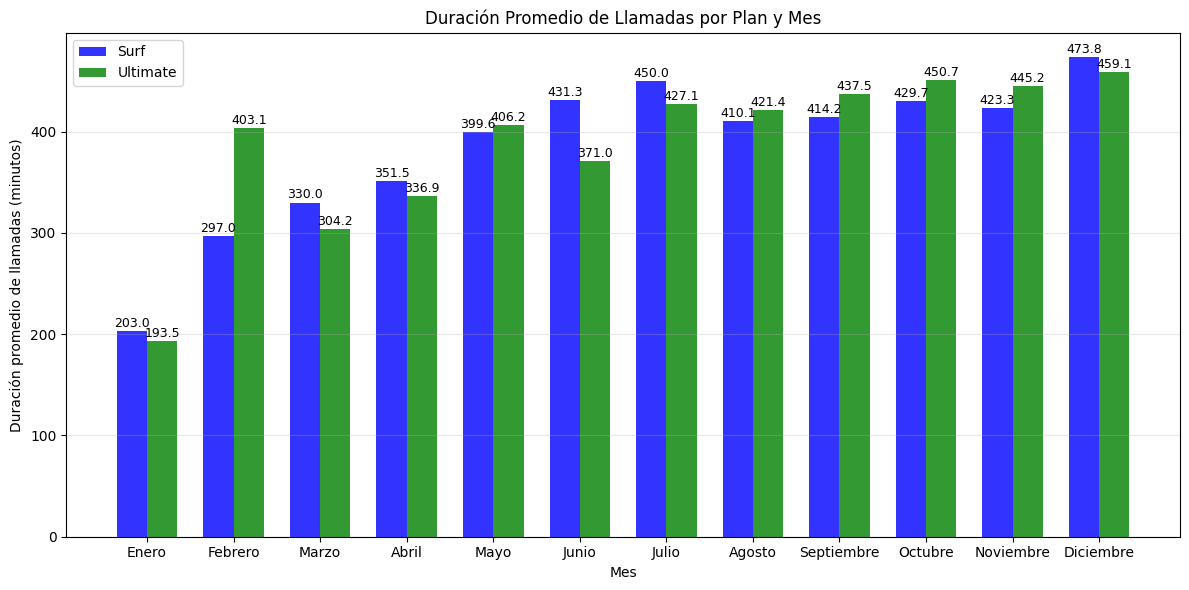

In [220]:
# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))

# Crear lista de nombres de meses en español
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Crear gráfico de barras agrupadas
surf_data = avg_call_duration[avg_call_duration['plan'] == 'surf']
ultimate_data = avg_call_duration[avg_call_duration['plan'] == 'ultimate']

x = np.arange(len(surf_data['month']))  # Posiciones en el eje x
width = 0.35  # Ancho de las barras

# Crear las barras
bars1 = plt.bar(x - width/2, surf_data['avg_minutes_per_month'], width,
                label='Surf', color='blue', alpha=0.8)
bars2 = plt.bar(x + width/2, ultimate_data['avg_minutes_per_month'], width,
                label='Ultimate', color='green', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Mes')
plt.ylabel('Duración promedio de llamadas (minutos)')
plt.title('Duración Promedio de Llamadas por Plan y Mes')

# Usar nombres de meses en lugar de números
plt.xticks(x, nombres_meses)  

plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar valores en las barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [253]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

# Separar los datos de minutos por plan
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['minutes_used']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['minutes_used']

# Calcular estadísticas descriptivas
print("Estadísticas de minutos mensuales por plan:")
print("\nPlan Surf:")
print(f"Mínimo: {surf_minutes.min():.2f} minutos")
print(f"Máximo: {surf_minutes.max():.2f} minutos")
print(f"Media: {surf_minutes.mean():.2f} minutos")
print(f"Mediana: {surf_minutes.median():.2f} minutos")
print(f"Desviación estándar: {surf_minutes.std():.2f}")

print("\nPlan Ultimate:")
print(f"Mínimo: {ultimate_minutes.min():.2f} minutos")
print(f"Máximo: {ultimate_minutes.max():.2f} minutos")
print(f"Media: {ultimate_minutes.mean():.2f} minutos")
print(f"Mediana: {ultimate_minutes.median():.2f} minutos")
print(f"Desviación estándar: {ultimate_minutes.std():.2f}")

Estadísticas de minutos mensuales por plan:

Plan Surf:
Mínimo: 0.00 minutos
Máximo: 1510.00 minutos
Media: 428.75 minutos
Mediana: 425.00 minutos
Desviación estándar: 234.45

Plan Ultimate:
Mínimo: 0.00 minutos
Máximo: 1369.00 minutos
Media: 430.45 minutos
Mediana: 424.00 minutos
Desviación estándar: 240.51


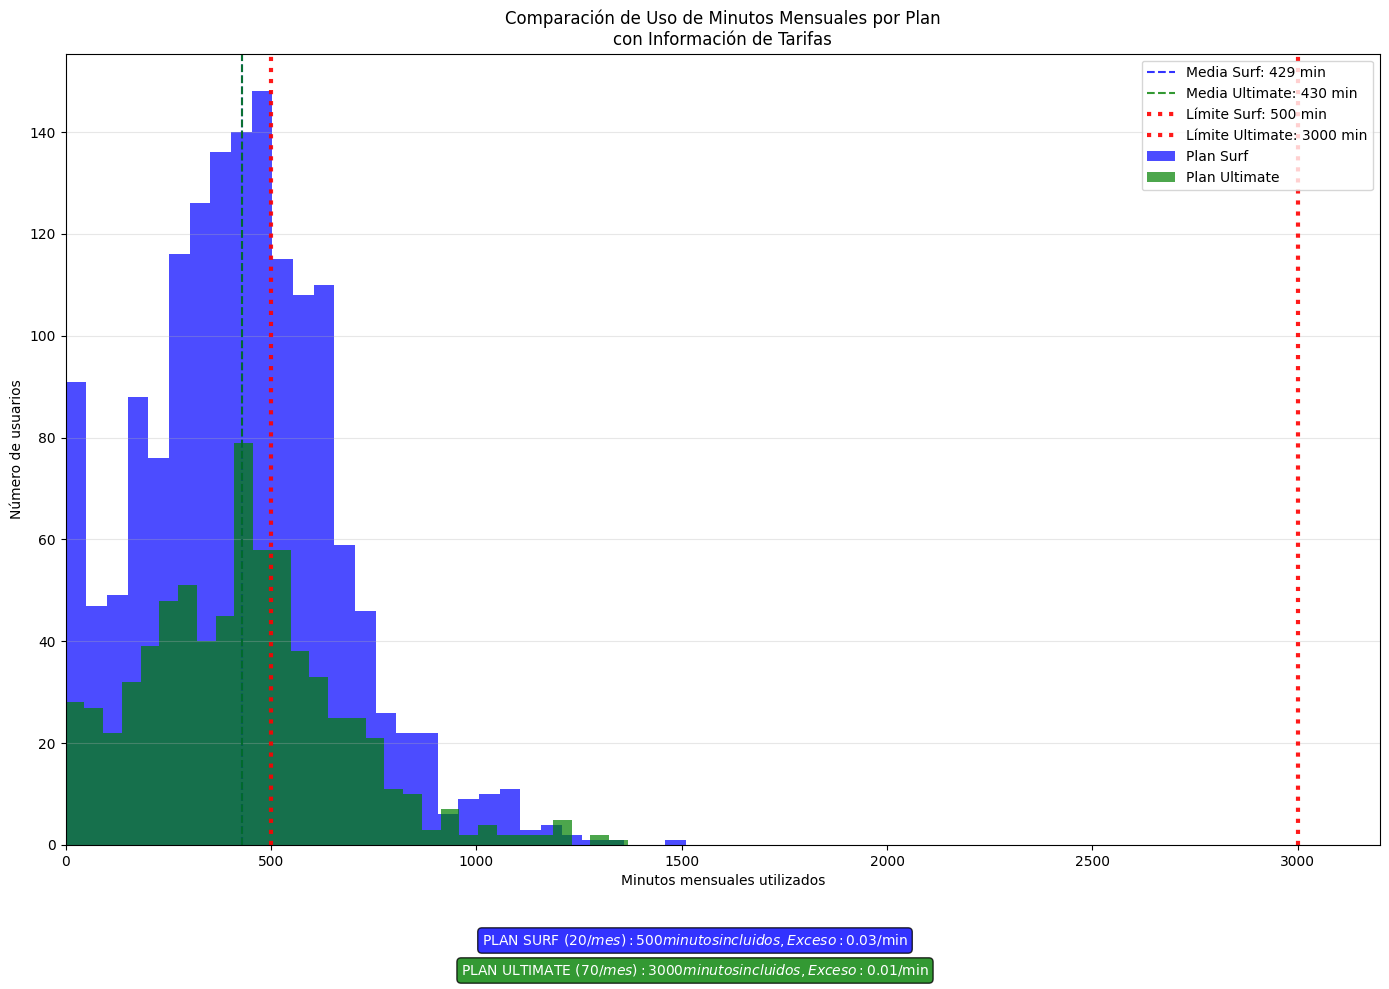

In [221]:
# Crear histograma optimizado para comparar uso de minutos mensuales
plt.figure(figsize=(14, 10))

# Separar los datos de minutos por plan
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['minutes_used']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['minutes_used']

# Crear histograma
plt.hist(surf_minutes, bins=30, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(ultimate_minutes, bins=30, alpha=0.7, label='Plan Ultimate', color='green')

# Etiquetas y título
plt.xlabel('Minutos mensuales utilizados')
plt.ylabel('Número de usuarios')
plt.title('Comparación de Uso de Minutos Mensuales por Plan\ncon Información de Tarifas')

# Líneas verticales para las medias (mantener colores originales)
plt.axvline(surf_minutes.mean(), color='blue', linestyle='--', alpha=0.8,
           label=f'Media Surf: {surf_minutes.mean():.0f} min')
plt.axvline(ultimate_minutes.mean(), color='green', linestyle='--', alpha=0.8,
           label=f'Media Ultimate: {ultimate_minutes.mean():.0f} min')

# Líneas verticales para límites en ROJO para destacar
plt.axvline(500, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Límite Surf: 500 min')
plt.axvline(3000, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Límite Ultimate: 3000 min')

# Rango para mostrar el límite de 3000 y la capacidad no utilizada
plt.xlim(0, 3200)  # Mostrar hasta 3200 para incluir el límite de 3000

# Información de los planes con colores coordinados
textstr1 = 'PLAN SURF ($20/mes): 500 minutos incluidos, Exceso: $0.03/min'
textstr2 = 'PLAN ULTIMATE ($70/mes): 3000 minutos incluidos, Exceso: $0.01/min'

# Texto con colores coordinados y letras blancas
plt.figtext(0.5, 0.05, textstr1, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='blue', alpha=0.8))
plt.figtext(0.5, 0.02, textstr2, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))

# Configuración final
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Dar espacio para el texto inferior
plt.show()

In [189]:
# Calcula la media y la varianza de la duración mensual de llamadas.

# Calcular estadísticas descriptivas para minutos mensuales por plan
print(" ESTADÍSTICAS DE MINUTOS MENSUALES POR PLAN \n")

# Separar los datos por plan
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['minutes_used']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['minutes_used']

# Calcular estadísticas para Plan Surf
print("PLAN SURF:")
print(f"Media: {surf_minutes.mean():.2f} minutos")
print(f"Varianza: {surf_minutes.var():.2f}")
print(f"Desviación estándar: {surf_minutes.std():.2f}")

print("\nPLAN ULTIMATE:")
print(f"Media: {ultimate_minutes.mean():.2f} minutos")
print(f"Varianza: {ultimate_minutes.var():.2f}")
print(f"Desviación estándar: {ultimate_minutes.std():.2f}")


 ESTADÍSTICAS DE MINUTOS MENSUALES POR PLAN 

PLAN SURF:
Media: 428.75 minutos
Varianza: 54968.28
Desviación estándar: 234.45

PLAN ULTIMATE:
Media: 430.45 minutos
Varianza: 57844.46
Desviación estándar: 240.51


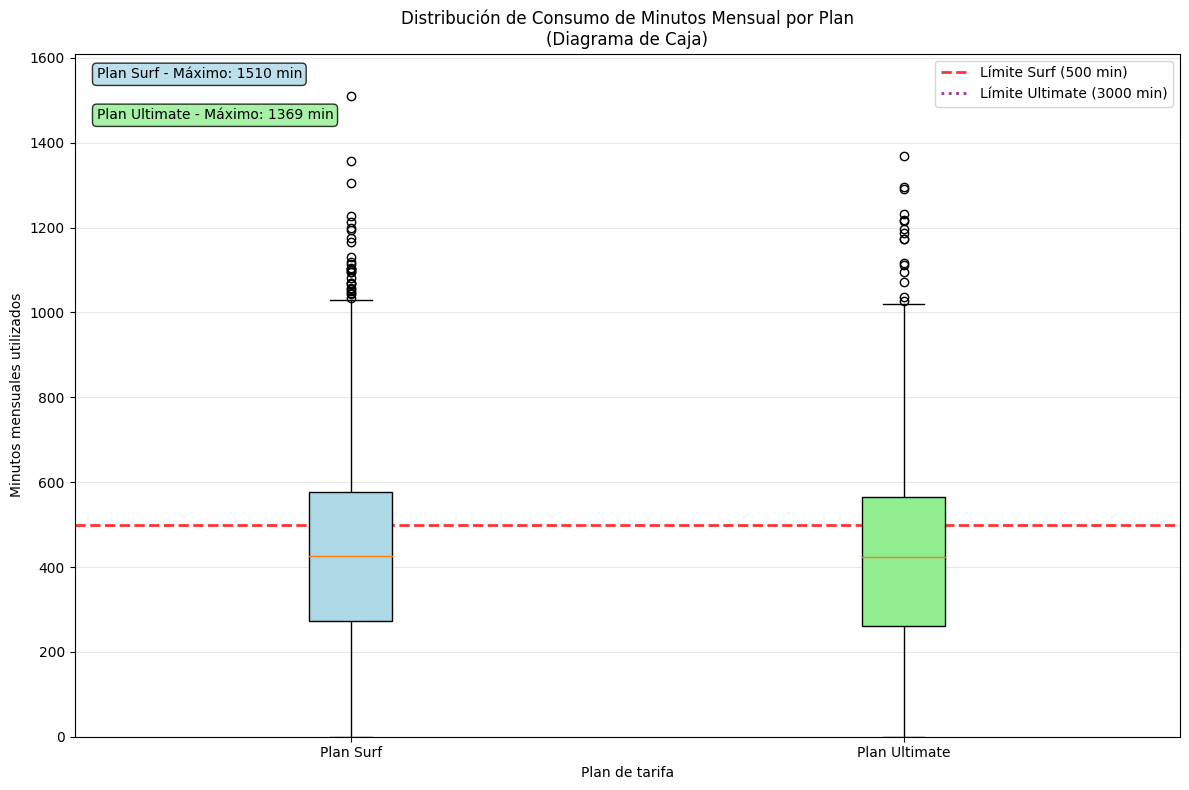

In [222]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Crear boxplot mejorado para comparar distribución de minutos por plan
plt.figure(figsize=(12, 8))

# Separar datos por plan
surf_minutes = monthly_data[monthly_data['plan'] == 'surf']['minutes_used']
ultimate_minutes = monthly_data[monthly_data['plan'] == 'ultimate']['minutes_used']

# Crear boxplot
box_data = [surf_minutes, ultimate_minutes]
labels = ['Plan Surf', 'Plan Ultimate']

bp = plt.boxplot(box_data, labels=labels, patch_artist=True, 
                 showfliers=True)  # Asegurar que se muestren los outliers

# Colorear las cajas
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')

# Líneas horizontales para los límites de los planes
plt.axhline(y=500, color='red', linestyle='--', linewidth=2, alpha=0.8,
            label='Límite Surf (500 min)')
plt.axhline(y=3000, color='purple', linestyle=':', linewidth=2, alpha=0.8,
            label='Límite Ultimate (3000 min)')

# Límite del eje Y para mostrar todos los valores
max_value = max(surf_minutes.max(), ultimate_minutes.max())
plt.ylim(0, max_value + 100)  # Agregar margen superior

# Etiquetas y título
plt.ylabel('Minutos mensuales utilizados')
plt.xlabel('Plan de tarifa')
plt.title('Distribución de Consumo de Minutos Mensual por Plan\n(Diagrama de Caja)')

# Grid para mejor lectura
plt.grid(axis='y', alpha=0.3)

# Etiquetas de máximo como en el gráfico de GB
plt.text(0.02, 0.98, f'Plan Surf - Máximo: {surf_minutes.max():.0f} min', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.text(0.02, 0.92, f'Plan Ultimate - Máximo: {ultimate_minutes.max():.0f} min', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Leyenda mejorada
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

**CONCLUSIONES SOBRE EL COMPORTAMIENTO DE LOS USUARIOS EN RELACIÓN CON LOS MINUTOS CONSUMIDOS (POR PLAN)**

A partir del análisis de los minutos utilizados mensualmente en los planes Surf y Ultimate, se observa que el comportamiento de los usuarios es muy similar, a pesar de que las tarifas ofrecen límites completamente distintos:

- Comportamiento por mes: 

  - Enero es el mes con menor consumo promedio, con aproximadamente 360 minutos por usuario. Esto sugiere que la actividad disminuye después de las festividades de fin de año.

  - Diciembre es el mes con mayor consumo, alcanzando un promedio cercano a 470–480 minutos, lo que coincide con la temporada alta de comunicaciones por reuniones, compras y festividades.

  - La mayor diferencia entre los promedios de consumo entre planes se presenta en febrero, con una brecha aproximada de ~40 minutos, siendo el mes donde más se separa el comportamiento entre Surf y Ultimate.  Esto sugiere un posible cambio temporal de hábitos, aunque no es una tendencia constante durante el año.


- Consumo promedio muy parecido:

  - Surf: 428.75 minutos al mes

  - Ultimate: 430.45 minutos al mes

La diferencia es prácticamente nula (≈ 2 minutos), lo que indica que el tipo de plan no está influyendo en la cantidad de minutos que los usuarios realmente consumen.


- Variabilidad similar:

  - Surf – Desviación estándar: ~234.45

  - Ultimate – Desviación estándar: ~240.51

Esto demuestra que ambos grupos tienen patrones de uso igual de dispersos, es decir, hay usuarios que hablan muy poco y otros que hablan mucho, sin diferencias marcadas entre los planes.


- Comportamiento respecto a los límites de los planes:

  - Plan Surf: límite de 500 min/mes. Máximo uso observado: 1510 min, lo que muestra que algunos usuarios exceden de forma significativa el límite, generando cargos adicionales.

  - Plan Ultimate: límite de 3000 min/mes. Máximo uso observado: 1369 min, que está muy por debajo del límite del plan.

Esto evidencia que los usuarios del plan Ultimate no llegan siquiera a utilizar la mitad del beneficio incluido. En contraste, los usuarios de Surf sí tienden a exceder su límite, lo que probablemente incrementa los ingresos por cargos extra.


- Distribución del consumo (Según Los histogramas):

  - En ambos planes, la mayoría de los usuarios consume entre 200 y 600 minutos al mes.

  - No existe un grupo considerable de usuarios que se acerque al límite de 3000 minutos del plan Ultimate.

  - Los picos de consumo muy alto (más de 1000 minutos) son excepcionales y aparecen en ambos planes.

  - El histograma de distribución de minutos mensuales por plan muestra claramente que existe aproximadamente el doble de usuarios del Plan Surf comparado con el Plan Ultimate.

    

**Conclusión final**

A lo largo del año, el consumo muestra estacionalidad: mínimos en enero y máximos en diciembre, lo cual puede ser relevante para la planificación de capacidad y campañas promocionales.

El consumo de minutos no depende del plan contratado. Los usuarios, en promedio, hablan prácticamente lo mismo sin importar si tienen el plan básico (Surf) o el plan premium (Ultimate). Además, se observa que:

El límite de 3000 minutos del plan Ultimate está ampliamente subutilizado.

En cambio, en el plan Surf, sí existen usuarios que superan el límite de 500 minutos, lo cual genera ingresos adicionales para la empresa.

Esto sugiere que el plan Ultimate podría estar ofreciendo mucho más de lo que la mayoría de los usuarios realmente necesita, mientras que el plan Surf podría estar generando ingresos extra por los minutos excedidos.

### Mensajes

In [203]:
# Calcular el promedio de mensajes por plan y mes
avg_messages = monthly_data.groupby(['plan', 'month']).agg({
    'messages_count': 'mean'
}).reset_index()

# Renombrar la columna para mayor claridad
avg_messages.rename(columns={'messages_count': 'avg_messages_per_month'}, inplace=True)

# Verificar el resultado
print("Promedio de mensajes por plan y mes:")
avg_messages.round(2)

Promedio de mensajes por plan y mes:


,plan,month,avg_messages_per_month
0,surf,1,10.50
1,surf,2,12.00
2,surf,3,15.26
3,surf,4,17.40
4,surf,5,24.01
5,surf,6,25.30
6,surf,7,27.03
7,surf,8,28.78
8,surf,9,30.76
9,surf,10,33.84


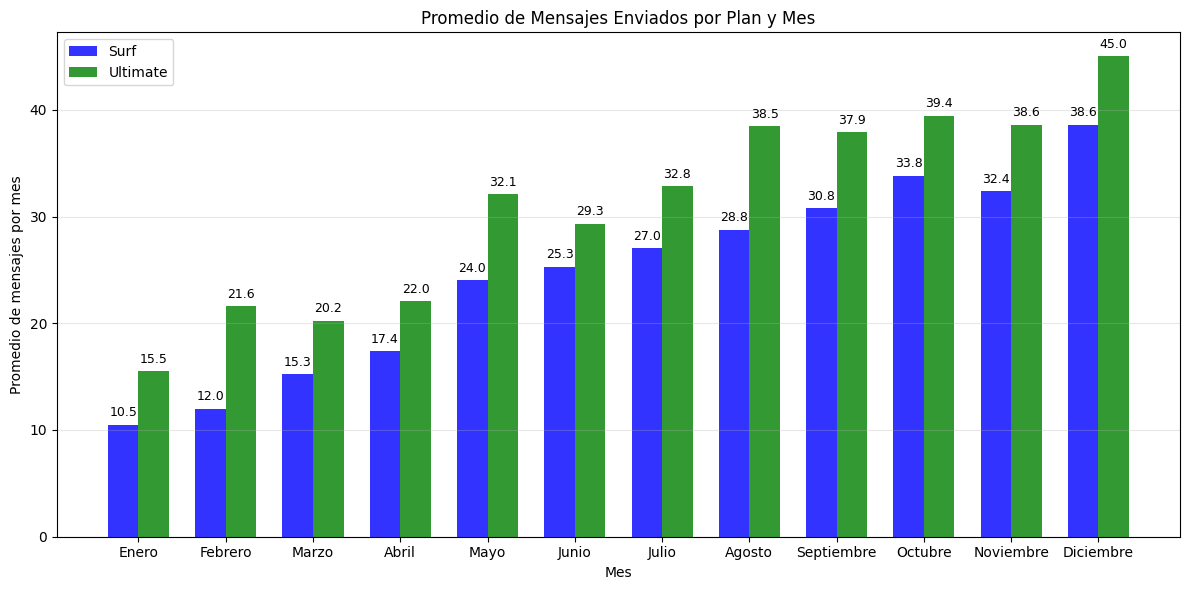

In [204]:
# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))

# Crear lista de nombres de meses
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Crear gráfico de barras agrupadas
surf_data = avg_messages[avg_messages['plan'] == 'surf']
ultimate_data = avg_messages[avg_messages['plan'] == 'ultimate']

x = np.arange(len(surf_data['month']))  # Posiciones en el eje x
width = 0.35  # Ancho de las barras

# Crear las barras
bars1 = plt.bar(x - width/2, surf_data['avg_messages_per_month'], width,
                label='Surf', color='blue', alpha=0.8)
bars2 = plt.bar(x + width/2, ultimate_data['avg_messages_per_month'], width,
                label='Ultimate', color='green', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Mes')
plt.ylabel('Promedio de mensajes por mes')
plt.title('Promedio de Mensajes Enviados por Plan y Mes')


plt.xticks(x, nombres_meses)  # Usar nombres de meses en lugar de números

plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar valores en las barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [252]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

# Separar los datos de mensajes por plan
surf_messages = monthly_data[monthly_data['plan'] == 'surf']['messages_count']
ultimate_messages = monthly_data[monthly_data['plan'] == 'ultimate']['messages_count']

# Calcular estadísticas descriptivas
print("Estadísticas de mensajes mensuales por plan:")
print("\nPlan Surf:")
print(f"Mínimo: {surf_messages.min():.2f} mensajes")
print(f"Máximo: {surf_messages.max():.2f} mensajes")
print(f"Media: {surf_messages.mean():.2f} mensajes")
print(f"Mediana: {surf_messages.median():.2f} mensajes")
print(f"Desviación estándar: {surf_messages.std():.2f}")

print("\nPlan Ultimate:")
print(f"Mínimo: {ultimate_messages.min():.2f} mensajes")
print(f"Máximo: {ultimate_messages.max():.2f} mensajes")
print(f"Media: {ultimate_messages.mean():.2f} mensajes")
print(f"Mediana: {ultimate_messages.median():.2f} mensajes")
print(f"Desviación estándar: {ultimate_messages.std():.2f}")

Estadísticas de mensajes mensuales por plan:

Plan Surf:
Mínimo: 0.00 mensajes
Máximo: 266.00 mensajes
Media: 31.16 mensajes
Mediana: 24.00 mensajes
Desviación estándar: 33.57

Plan Ultimate:
Mínimo: 0.00 mensajes
Máximo: 166.00 mensajes
Media: 37.55 mensajes
Mediana: 30.00 mensajes
Desviación estándar: 34.77


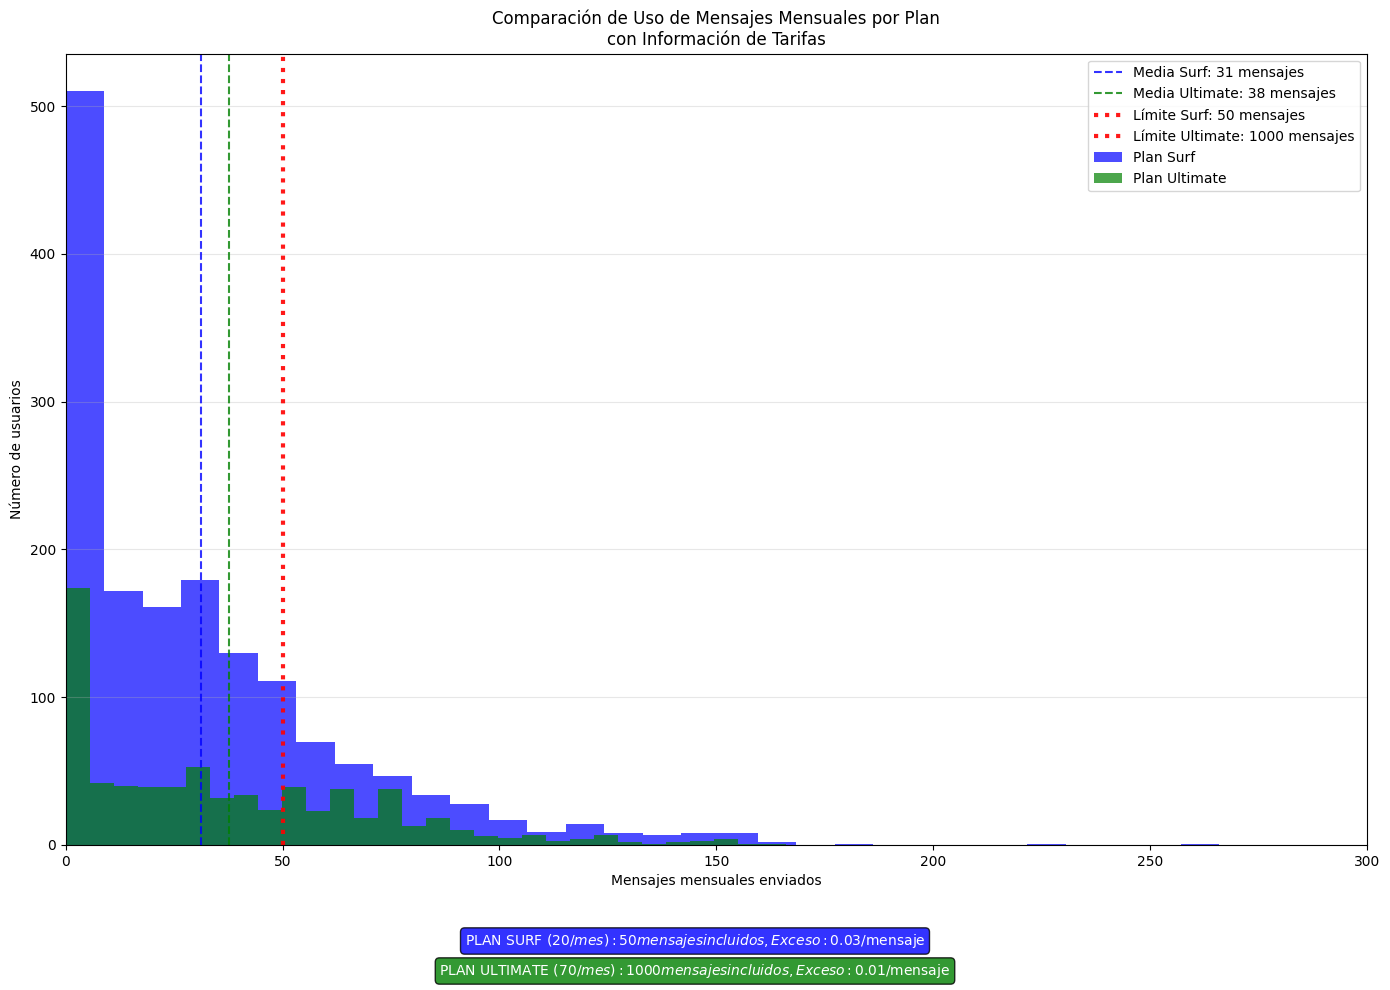

In [223]:
# Crear histograma optimizado para comparar uso de mensajes mensuales
plt.figure(figsize=(14, 10))

# Separar los datos de mensajes por plan
surf_messages = monthly_data[monthly_data['plan'] == 'surf']['messages_count']
ultimate_messages = monthly_data[monthly_data['plan'] == 'ultimate']['messages_count']

# Crear histograma
plt.hist(surf_messages, bins=30, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(ultimate_messages, bins=30, alpha=0.7, label='Plan Ultimate', color='green')

# Etiquetas y título
plt.xlabel('Mensajes mensuales enviados')
plt.ylabel('Número de usuarios')
plt.title('Comparación de Uso de Mensajes Mensuales por Plan\ncon Información de Tarifas')

# Líneas verticales para las medias (mantener colores originales)
plt.axvline(surf_messages.mean(), color='blue', linestyle='--', alpha=0.8,
           label=f'Media Surf: {surf_messages.mean():.0f} mensajes')
plt.axvline(ultimate_messages.mean(), color='green', linestyle='--', alpha=0.8,
           label=f'Media Ultimate: {ultimate_messages.mean():.0f} mensajes')

# Líneas verticales para límites en ROJO para destacar
plt.axvline(50, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Límite Surf: 50 mensajes')
plt.axvline(1000, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Límite Ultimate: 1000 mensajes')

# Rango para mostrar los límites y la capacidad no utilizada
plt.xlim(0, 300)  # Mostrar hasta 300 para incluir la mayoría de los datos

# Información de los planes con colores coordinados
textstr1 = 'PLAN SURF ($20/mes): 50 mensajes incluidos, Exceso: $0.03/mensaje'
textstr2 = 'PLAN ULTIMATE ($70/mes): 1000 mensajes incluidos, Exceso: $0.01/mensaje'

# Texto con colores coordinados y letras blancas
plt.figtext(0.5, 0.05, textstr1, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='blue', alpha=0.8))
plt.figtext(0.5, 0.02, textstr2, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))

# Configuración final
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Dar espacio para el texto inferior
plt.show()

In [207]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# Calcular estadísticas descriptivas para mensajes mensuales por plan
print(" ESTADÍSTICAS DE MENSAJES MENSUALES POR PLAN \n")

# Separar los datos por plan
surf_messages = monthly_data[monthly_data['plan'] == 'surf']['messages_count']
ultimate_messages = monthly_data[monthly_data['plan'] == 'ultimate']['messages_count']

# Calcular estadísticas para Plan Surf
print("PLAN SURF:")
print(f"Media: {surf_messages.mean():.2f} mensajes")
print(f"Varianza: {surf_messages.var():.2f}")
print(f"Desviación estándar: {surf_messages.std():.2f}")

print("\nPLAN ULTIMATE:")
print(f"Media: {ultimate_messages.mean():.2f} mensajes")
print(f"Varianza: {ultimate_messages.var():.2f}")
print(f"Desviación estándar: {ultimate_messages.std():.2f}")

 ESTADÍSTICAS DE MENSAJES MENSUALES POR PLAN 

PLAN SURF:
Media: 31.16 mensajes
Varianza: 1126.72
Desviación estándar: 33.57

PLAN ULTIMATE:
Media: 37.55 mensajes
Varianza: 1208.76
Desviación estándar: 34.77


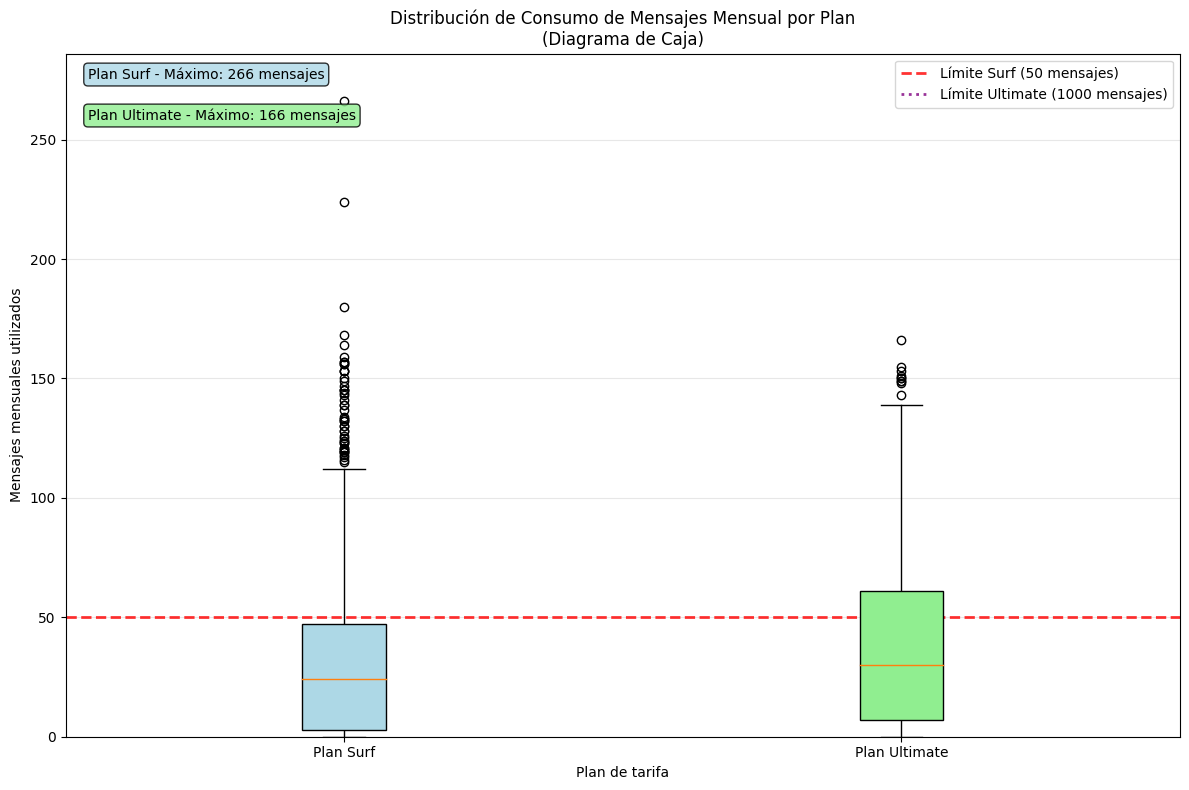

In [224]:
# Traza un diagrama de caja para visualizar la distribución de mensajes mensuales

# Crear boxplot mejorado para comparar distribución de mensajes por plan
plt.figure(figsize=(12, 8))

# Separar datos por plan - CORRECCIÓN: usar 'messages_count' en lugar de 'messages_used'
surf_messages = monthly_data[monthly_data['plan'] == 'surf']['messages_count']
ultimate_messages = monthly_data[monthly_data['plan'] == 'ultimate']['messages_count']

# Crear boxplot
box_data = [surf_messages, ultimate_messages]
labels = ['Plan Surf', 'Plan Ultimate']
bp = plt.boxplot(box_data, labels=labels, patch_artist=True,
                showfliers=True)  # Asegurar que se muestren los outliers

# Colorear las cajas
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')

# Líneas horizontales para los límites de los planes
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.8,
           label='Límite Surf (50 mensajes)')
plt.axhline(y=1000, color='purple', linestyle=':', linewidth=2, alpha=0.8,
           label='Límite Ultimate (1000 mensajes)')

# Límite del eje Y para mostrar todos los valores
max_value = max(surf_messages.max(), ultimate_messages.max())
plt.ylim(0, max_value + 20)  # Agregar margen superior

# Etiquetas y título
plt.ylabel('Mensajes mensuales utilizados')
plt.xlabel('Plan de tarifa')
plt.title('Distribución de Consumo de Mensajes Mensual por Plan\n(Diagrama de Caja)')

# Grid para mejor lectura
plt.grid(axis='y', alpha=0.3)

# Etiquetas de máximo
plt.text(0.02, 0.98, f'Plan Surf - Máximo: {surf_messages.max():.0f} mensajes',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
plt.text(0.02, 0.92, f'Plan Ultimate - Máximo: {ultimate_messages.max():.0f} mensajes',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Leyenda mejorada
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**CONCLUSIONES SOBRE EL COMPORTAMIENTO DE LOS USUARIOS EN RELACIÓN CON LOS MENSAJES ENVIADOS (SMS) POR MES Y POR PLAN**

A partir del análisis del envío mensual de SMS en los planes Surf y Ultimate, se observa que los patrones de comportamiento entre ambos grupos presentan similitudes importantes, aunque con algunas diferencias que conviene destacar.

- Comportamiento por mes:

  - Enero es el mes con menor consumo promedio, con aproximadamente 10.5 mensajes en Surf y 15.5 mensajes en Ultimate. Esto sugiere que la actividad disminuye después de las festividades de fin de año.

  - Diciembre es el mes con mayor consumo, alcanzando un promedio cercano a 38.6 mensajes en Surf y 45 mensajes en Ultimate, lo que coincide con la temporada alta de comunicaciones por reuniones, compras y festividades.

  - La mayor diferencia entre los promedios de consumo entre planes se presenta en febrero, con una brecha aproximada de 9.6 mensajes (12.0 en Surf vs. 21.6 en Ultimate), siendo el mes donde más se separa el comportamiento entre Surf y Ultimate. Esto sugiere un posible cambio temporal de hábitos, aunque no es una tendencia constante durante el año.

- Consumo promedio por plan: 

  - Surf: 31.16 mensajes al mes

  - Ultimate: 37.55 mensajes al mes

La diferencia entre ambos planes es moderada (6.4 mensajes), lo que indica que, aunque los usuarios del plan Ultimate envían ligeramente más mensajes en promedio, la cantidad de mensajes enviados no varía de forma drástica según el plan. El comportamiento general es similar entre ambos grupos.

- Variabilidad similar:

  - Surf – Desviación estándar: 33.57 mensajes

  - Ultimate – Desviación estándar: 34.77 mensajes

Esto demuestra que ambos grupos presentan un grado de dispersión muy parecido. Existen usuarios que envían muy pocos mensajes y otros que envían muchos, pero no se observan diferencias marcadas en la variabilidad del comportamiento entre los planes.


- Comportamiento respecto a los límites de los planes:

  - Plan Surf: límite de 50 mensajes/mes. Máximo uso observado: 266 mensajes, lo que evidencia que algunos usuarios exceden ampliamente el límite, generando cargos adicionales por mensajes extra.

  - Plan Ultimate: límite de 1000 mensajes/mes. Máximo uso observado: 166 mensajes, muy por debajo del límite del plan.

Esto muestra que los usuarios del plan Ultimate no alcanzan ni el 20% del beneficio incluido. En contraste, los usuarios de Surf presentan un uso más alto en proporción a su límite y, en algunos casos, lo exceden en más de 200 mensajes, lo cual genera ingresos adicionales por excedentes.

- Distribución del consumo (según los histogramas): 

  - En ambos planes, la mayoría de los usuarios envía entre 0 y 60 mensajes mensuales, concentrándose fuertemente en los valores más bajos.

  - No existe un grupo significativo de usuarios que se acerque al límite de 1000 mensajes del plan Ultimate; la distribución evidencia que la gran mayoría permanece en rangos muy inferiores.

  - Los picos de consumo alto (más de 150 mensajes) son poco frecuentes, aunque aparecen en ambos planes. Sin embargo, en Surf estos picos pueden ubicarse muy por encima del límite del plan, mientras que en Ultimate siguen estando muy lejos del umbral permitido.

  - El histograma muestra claramente que la cantidad de usuarios del plan Surf es aproximadamente el doble que la del plan Ultimate, lo cual explica la mayor presencia de valores extremos en Surf.
 

**Conclusión final**

A lo largo del año, el envío de mensajes muestra un patrón estacional claro: el consumo más bajo se registra en enero, mientras que diciembre presenta los valores promedio más altos. Esta tendencia puede ser relevante para la planificación de infraestructura y estrategias comerciales orientadas a periodos de mayor interacción móvil.

El consumo de mensajes no parece depender de forma determinante del plan contratado. En promedio, los usuarios del plan Ultimate envían apenas unos mensajes más que los usuarios de Surf, y la diferencia no es lo suficientemente grande como para indicar un comportamiento distinto entre los planes. Ambos grupos mantienen niveles de uso similares durante todo el año.

Además, se observa que:

El límite de 1000 mensajes mensuales del plan Ultimate está ampliamente subutilizado. Incluso los usuarios de mayor consumo en este plan se mantienen muy por debajo de dicha capacidad.

En el plan Surf, sí existen usuarios que superan el límite de 50 mensajes mensuales, en algunos casos por más de 200 mensajes, lo que provoca cargos adicionales y, por tanto, genera ingresos extra para la empresa.

En conjunto, estos resultados sugieren que el plan Ultimate ofrece una cantidad de mensajes que supera ampliamente las necesidades reales de la mayoría de los usuarios. Por otro lado, el plan Surf presenta mayor probabilidad de excedentes, lo que podría estar contribuyendo a ingresos adicionales para la compañía. En términos operativos y comerciales, este comportamiento indica que las diferencias en límites no se reflejan en diferencias significativas en el uso real, salvo en los usuarios del plan Surf que sobrepasan su cuota.

### Internet

In [209]:
# Compara el consumo promedio de GB por cada plan y por cada mes. Traza un gráfico de barras para visualizarlo.

# Calcular el consumo promedio de GB por plan y mes
avg_gb_consumption = monthly_data.groupby(['plan', 'month']).agg({
    'gb_used': 'mean'
}).reset_index()

# Renombrar la columna para mayor claridad
avg_gb_consumption.rename(columns={'gb_used': 'avg_gb_per_month'}, inplace=True)

# Verificar el resultado
print("Consumo promedio de GB por plan y mes:")
avg_gb_consumption.round(2)

Consumo promedio de GB por plan y mes:


,plan,month,avg_gb_per_month
0,surf,1,5.00
1,surf,2,12.22
2,surf,3,13.57
3,surf,4,12.22
4,surf,5,14.12
5,surf,6,15.48
6,surf,7,16.88
7,surf,8,16.88
8,surf,9,16.69
9,surf,10,17.41


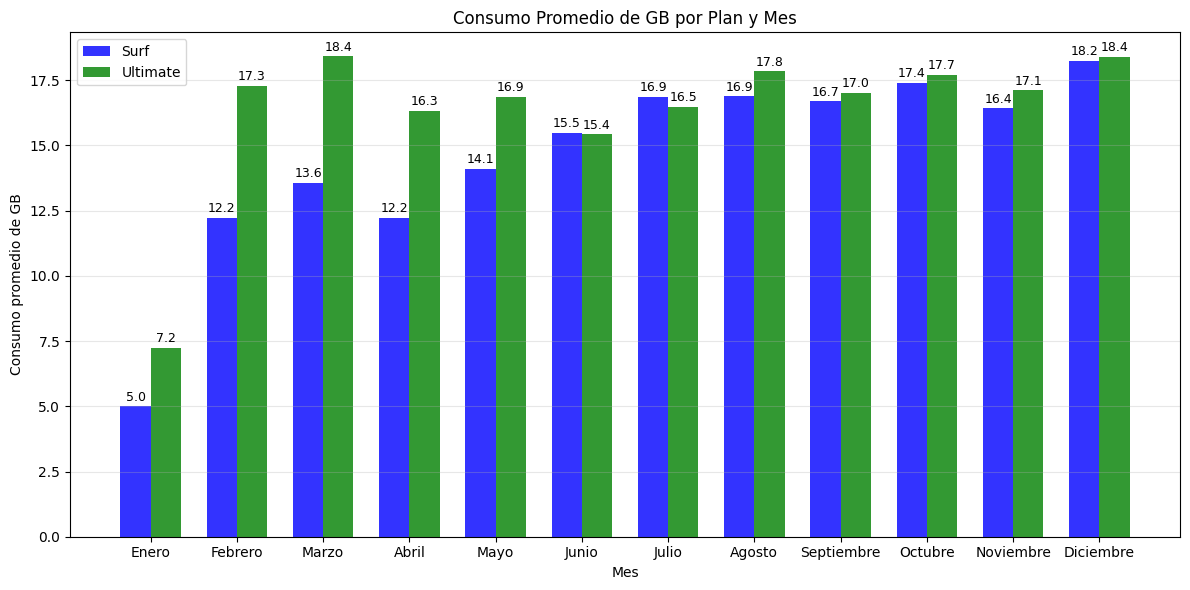

In [210]:
# Configurar el estilo del gráfico
plt.figure(figsize=(12, 6))

# Crear lista de nombres de meses en español
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

# Crear gráfico de barras agrupadas
surf_data = avg_gb_consumption[avg_gb_consumption['plan'] == 'surf']
ultimate_data = avg_gb_consumption[avg_gb_consumption['plan'] == 'ultimate']

x = np.arange(len(surf_data['month']))  # Posiciones en el eje x
width = 0.35  # Ancho de las barras

# Crear las barras
bars1 = plt.bar(x - width/2, surf_data['avg_gb_per_month'], width,
                label='Surf', color='blue', alpha=0.8)
bars2 = plt.bar(x + width/2, ultimate_data['avg_gb_per_month'], width,
                label='Ultimate', color='green', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Mes')
plt.ylabel('Consumo promedio de GB')
plt.title('Consumo Promedio de GB por Plan y Mes')
plt.xticks(x, nombres_meses)  # Usar nombres de meses en lugar de números
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Mostrar valores en las barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [251]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan

# Separar los datos de sesiones web por plan
surf_internet = monthly_data[monthly_data['plan'] == 'surf']['gb_used']
ultimate_internet = monthly_data[monthly_data['plan'] == 'ultimate']['gb_used']

# Calcular estadísticas descriptivas
print("Estadísticas de tráfico de Internet mensual por plan:")
print("\nPlan Surf:")
print(f"Mínimo: {surf_internet.min():.2f} GB")
print(f"Máximo: {surf_internet.max():.2f} GB")
print(f"Media: {surf_internet.mean():.2f} GB")
print(f"Mediana: {surf_internet.median():.2f} GB")
print(f"Desviación estándar: {surf_internet.std():.2f}")

print("\nPlan Ultimate:")
print(f"Mínimo: {ultimate_internet.min():.2f} GB")
print(f"Máximo: {ultimate_internet.max():.2f} GB")
print(f"Media: {ultimate_internet.mean():.2f} GB")
print(f"Mediana: {ultimate_internet.median():.2f} GB")
print(f"Desviación estándar: {ultimate_internet.std():.2f}")

Estadísticas de tráfico de Internet mensual por plan:

Plan Surf:
Mínimo: 0.00 GB
Máximo: 70.00 GB
Media: 16.67 GB
Mediana: 17.00 GB
Desviación estándar: 7.85

Plan Ultimate:
Mínimo: 0.00 GB
Máximo: 46.00 GB
Media: 17.31 GB
Mediana: 17.00 GB
Desviación estándar: 7.67


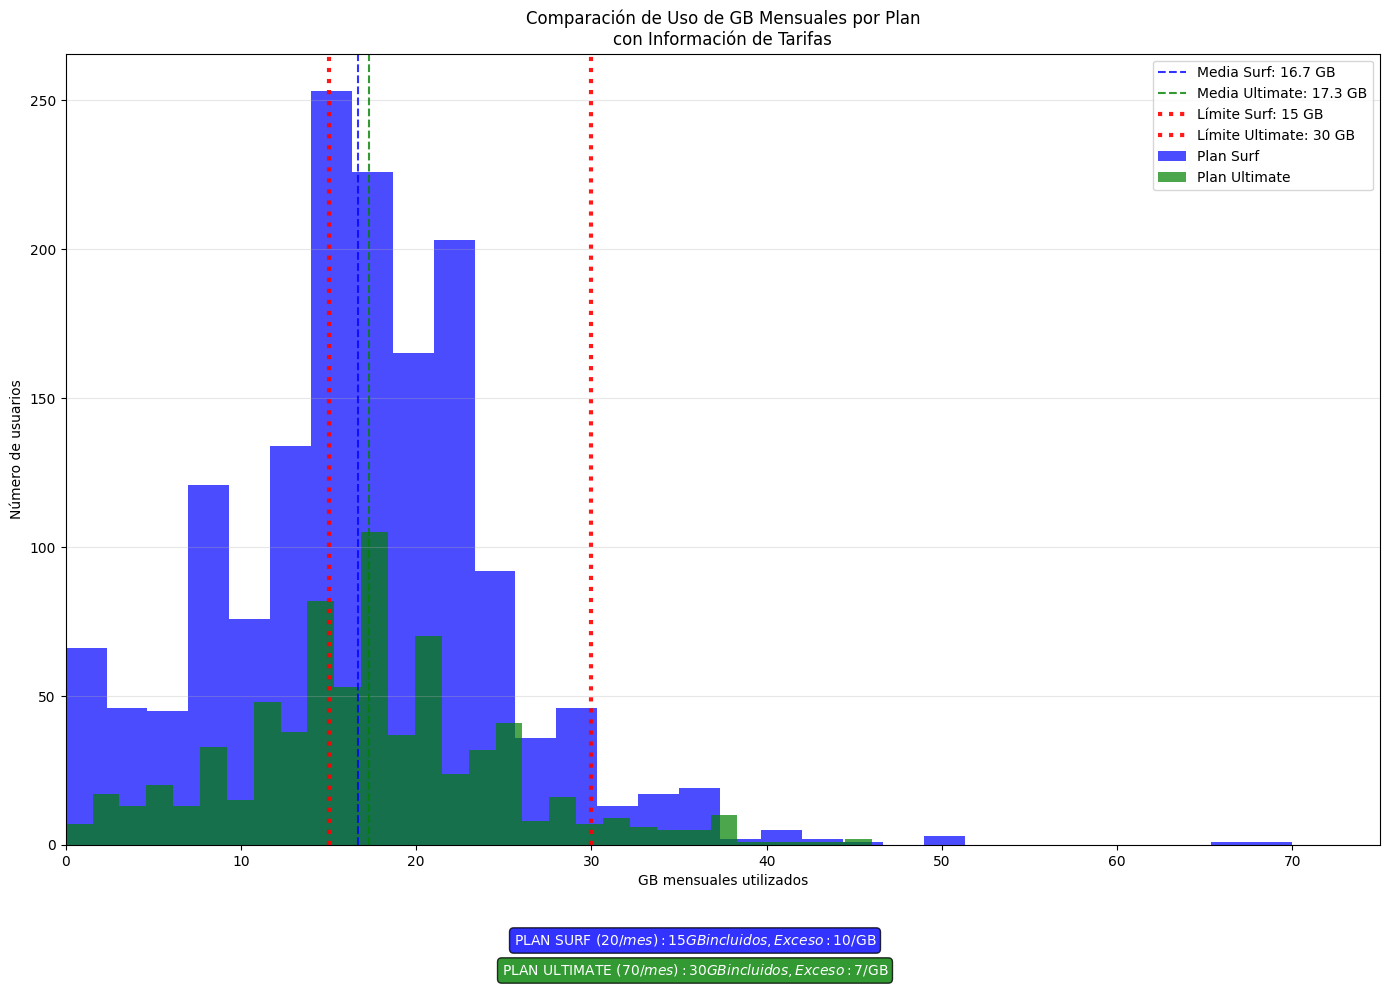

In [225]:
# Crear histograma optimizado para comparar uso de GB mensuales
plt.figure(figsize=(14, 10))

# Separar los datos de GB por plan
surf_gb = monthly_data[monthly_data['plan'] == 'surf']['gb_used']
ultimate_gb = monthly_data[monthly_data['plan'] == 'ultimate']['gb_used']

# Crear histograma
plt.hist(surf_gb, bins=30, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(ultimate_gb, bins=30, alpha=0.7, label='Plan Ultimate', color='green')

# Etiquetas y título
plt.xlabel('GB mensuales utilizados')
plt.ylabel('Número de usuarios')
plt.title('Comparación de Uso de GB Mensuales por Plan\ncon Información de Tarifas')

# Líneas verticales para las medias
plt.axvline(surf_gb.mean(), color='blue', linestyle='--', alpha=0.8,
            label=f'Media Surf: {surf_gb.mean():.1f} GB')
plt.axvline(ultimate_gb.mean(), color='green', linestyle='--', alpha=0.8,
            label=f'Media Ultimate: {ultimate_gb.mean():.1f} GB')

# Líneas verticales para límites
plt.axvline(15, color='red', linestyle=':', linewidth=3, alpha=0.9,
            label='Límite Surf: 15 GB')
plt.axvline(30, color='red', linestyle=':', linewidth=3, alpha=0.9,
            label='Límite Ultimate: 30 GB')

# Rango para mostrar el máximo de 70 GB
plt.xlim(0, 75) 

# Información de los planes
textstr1 = 'PLAN SURF ($20/mes): 15 GB incluidos, Exceso: $10/GB'
textstr2 = 'PLAN ULTIMATE ($70/mes): 30 GB incluidos, Exceso: $7/GB'

plt.figtext(0.5, 0.05, textstr1, ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='blue', alpha=0.8))
plt.figtext(0.5, 0.02, textstr2, ha='center', fontsize=10, color='white',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.8))

# Configuración final
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [213]:
# Calcular la media y la varianza del tráfico de internet mensual
print(" ESTADÍSTICAS DE TRÁFICO DE INTERNET MENSUALES POR PLAN \n")

# Calcular estadísticas para Plan Surf
print("PLAN SURF:")
print(f"Media: {surf_internet.mean():.2f} GB")
print(f"Varianza: {surf_internet.var():.2f}")
print(f"Desviación estándar: {surf_internet.std():.2f}")

print("\nPLAN ULTIMATE:")
print(f"Media: {ultimate_internet.mean():.2f} GB")
print(f"Varianza: {ultimate_internet.var():.2f}")
print(f"Desviación estándar: {ultimate_internet.std():.2f}")

 ESTADÍSTICAS DE TRÁFICO DE INTERNET MENSUALES POR PLAN 

PLAN SURF:
Media: 16.67 GB
Varianza: 61.58
Desviación estándar: 7.85

PLAN ULTIMATE:
Media: 17.31 GB
Varianza: 58.83
Desviación estándar: 7.67


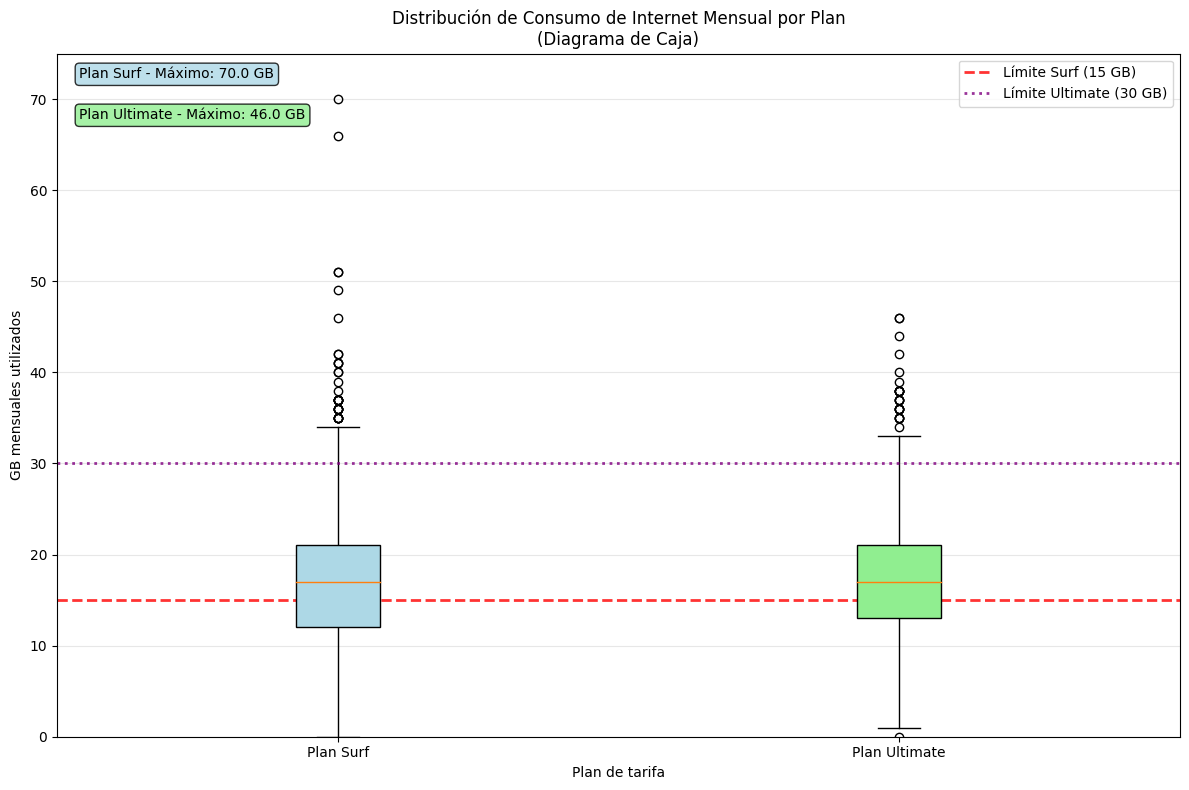

In [226]:
# Crear boxplot para comparar distribución de GB por plan
plt.figure(figsize=(12, 8))

# Separar datos por plan
surf_gb = monthly_data[monthly_data['plan'] == 'surf']['gb_used']
ultimate_gb = monthly_data[monthly_data['plan'] == 'ultimate']['gb_used']

# Crear boxplot
box_data = [surf_gb, ultimate_gb]
labels = ['Plan Surf', 'Plan Ultimate']

bp = plt.boxplot(box_data, labels=labels, patch_artist=True, 
                 showfliers=True)  # Asegurar que se muestren los outliers

# Colorear las cajas
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')

# Líneas horizontales para los límites de los planes
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.8,
            label='Límite Surf (15 GB)')
plt.axhline(y=30, color='purple', linestyle=':', linewidth=2, alpha=0.8,
            label='Límite Ultimate (30 GB)')

# Límite del eje Y para mostrar hasta 75 GB
plt.ylim(0, 75)  

# Etiquetas y título
plt.ylabel('GB mensuales utilizados')
plt.xlabel('Plan de tarifa')
plt.title('Distribución de Consumo de Internet Mensual por Plan\n(Diagrama de Caja)')

# Grid para mejor lectura
plt.grid(axis='y', alpha=0.3)

# Leyenda
plt.legend()

# Mostrar estadísticas en el gráfico
plt.text(0.02, 0.98, f'Plan Surf - Máximo: {surf_gb.max():.1f} GB', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.text(0.02, 0.92, f'Plan Ultimate - Máximo: {ultimate_gb.max():.1f} GB', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

**CONCLUSIONES SOBRE EL COMPORTAMIENTO DE LOS USUARIOS EN RELACIÓN CON EL TRÁFICO DE INTERNET (POR PLAN)**

A partir del análisis del tráfico mensual de Internet para los planes Surf y Ultimate, se observa que el comportamiento general de los usuarios es muy parecido entre ambos planes, aunque existen diferencias importantes cuando se comparan los límites incluidos en cada tarifa.

- Comportamiento por mes:

Ambos planes muestran un patrón estacional claro:

Enero es el mes de menor consumo (Surf: 5 GB; Ultimate: 7.2 GB).

El uso aumenta de forma consistente entre febrero y mayo.

En diciembre se observa el máximo consumo promedio (Surf: 18.2 GB; Ultimate: 18.4 GB), coincidiendo con temporadas de vacaciones, mayor ocio y uso intensivo de Internet.

La diferencia mensual entre planes es muy pequeña (entre 0.1 en junio y 5.1 GB en febrero), lo cual indica que el tipo de plan no determina cuántos GB consumen realmente los usuarios a lo largo del año.

- Consumo promedio muy similar:

  - Surf: 16.67 GB al mes

  - Ultimate: 17.31 GB al mes

La diferencia es tan solo de 0.64 GB, lo cual indica que los usuarios de ambos planes tienen prácticamente la misma necesidad mensual de Internet.

- Variabilidad parecida entre los planes:

  - Surf – Desviación estándar: 7.85 GB

  - Ultimate – Desviación estándar: 7.67 GB

Esto refleja que la dispersión en el comportamiento es casi idéntica en ambos grupos: hay usuarios que consumen muy poco y usuarios que consumen mucho, sin diferencias marcadas entre planes.

- Comportamiento respecto a los límites de los planes:

  - Plan Surf (15 GB incluidos): El promedio (16.67 GB) supera el límite del plan. Es común que los usuarios excedan los 15 GB mensuales, lo que genera cargos adicionales frecuentes. Los histogramas y el diagrama de caja muestran múltiples casos por encima de 20 GB e incluso valores extremos de hasta 70 GB.

  - Plan Ultimate (30 GB incluidos): El promedio (17.31 GB) está muy por debajo del límite de 30 GB. La mayoría de los usuarios no alcanza ni la mitad del beneficio incluido. Aunque hay algunos valores elevados (máximo: 46 GB), el exceso es poco común. Esto sugiere que Surf está subdimensionado para el consumo real, mientras que Ultimate tiene un límite muy holgado para las necesidades típicas del usuario.

- Distribución del consumo (según los histogramas):

  - En ambos planes, la mayoría de los usuarios consume entre 10 y 25 GB al mes.

  - Los consumos extremadamente altos (más de 40 GB) son poco frecuentes pero aparecen principalmente en el plan Surf.

  - El histograma evidencia que Surf tiene más usuarios por encima de su límite (15 GB) en comparación con Ultimate.


**Conclusión final**

Los resultados muestran que los usuarios de ambos planes tienen un comportamiento muy similar en cuanto al uso de Internet, con consumos promedio casi iguales y variabilidades prácticamente idénticas. Sin embargo, cuando se comparan estos patrones con los límites de cada plan, se observa una diferencia significativa: el plan Surf se queda corto para la mayoría de sus usuarios, quienes superan con frecuencia los 15 GB incluidos. Esto implica costos adicionales que incrementan los ingresos para la compañía.

En contraste, el plan Ultimate ofrece un margen muy amplio, con usuarios que en promedio usan poco más de la mitad de los 30 GB permitidos. Esto indica que, desde el punto de vista del consumo real, la mayoría de los usuarios no necesita un límite tan alto, mientras que quienes están en Surf probablemente generan más ingresos por cargos extra.


## Ingreso

In [232]:
# Agrupar ingresos por plan y por mes
revenue_by_plan_month = monthly_data.groupby(['plan', 'month']).agg({
    'monthly_revenue': ['sum', 'mean', 'count']
}).round(2)

# Aplanar las columnas para mayor claridad
revenue_by_plan_month.columns = ['total_revenue', 'avg_revenue_per_user', 'users_count']
revenue_by_plan_month = revenue_by_plan_month.reset_index()

# Mostrar los primeros resultados
print("Ingresos agrupados por plan y mes:")
revenue_by_plan_month.head(24)

Ingresos agrupados por plan y mes:


,plan,month,total_revenue,avg_revenue_per_user,users_count
0,surf,1,40.00,20.00,2
1,surf,2,309.57,34.40,9
2,surf,3,1056.65,45.94,23
3,surf,4,2035.53,40.71,50
4,surf,5,3667.37,47.63,77
5,surf,6,4779.80,49.28,97
6,surf,7,7583.56,62.67,121
7,surf,8,10356.85,63.93,162
8,surf,9,11304.67,58.27,194
9,surf,10,15504.83,65.42,237


In [241]:
# Crear tabla pivote para ingresos totales
ingresos_pivot = revenue_by_plan_month.pivot(
    index='month', 
    columns='plan', 
    values='total_revenue'
).fillna(0)

# Crear tabla pivote para cantidad de usuarios
usuarios_pivot = revenue_by_plan_month.pivot(
    index='month', 
    columns='plan', 
    values='users_count'
).fillna(0)

print("TABLA PIVOTE - INGRESOS TOTALES POR MES Y PLAN:")
ingresos_pivot

TABLA PIVOTE - INGRESOS TOTALES POR MES Y PLAN:


plan,surf,ultimate
month,,
1,40.00,280.0
2,309.57,490.0
3,1056.65,896.0
4,2035.53,1533.0
5,3667.37,2051.0
6,4779.80,3367.0
7,7583.56,4242.0
8,10356.85,5173.0
9,11304.67,6195.0


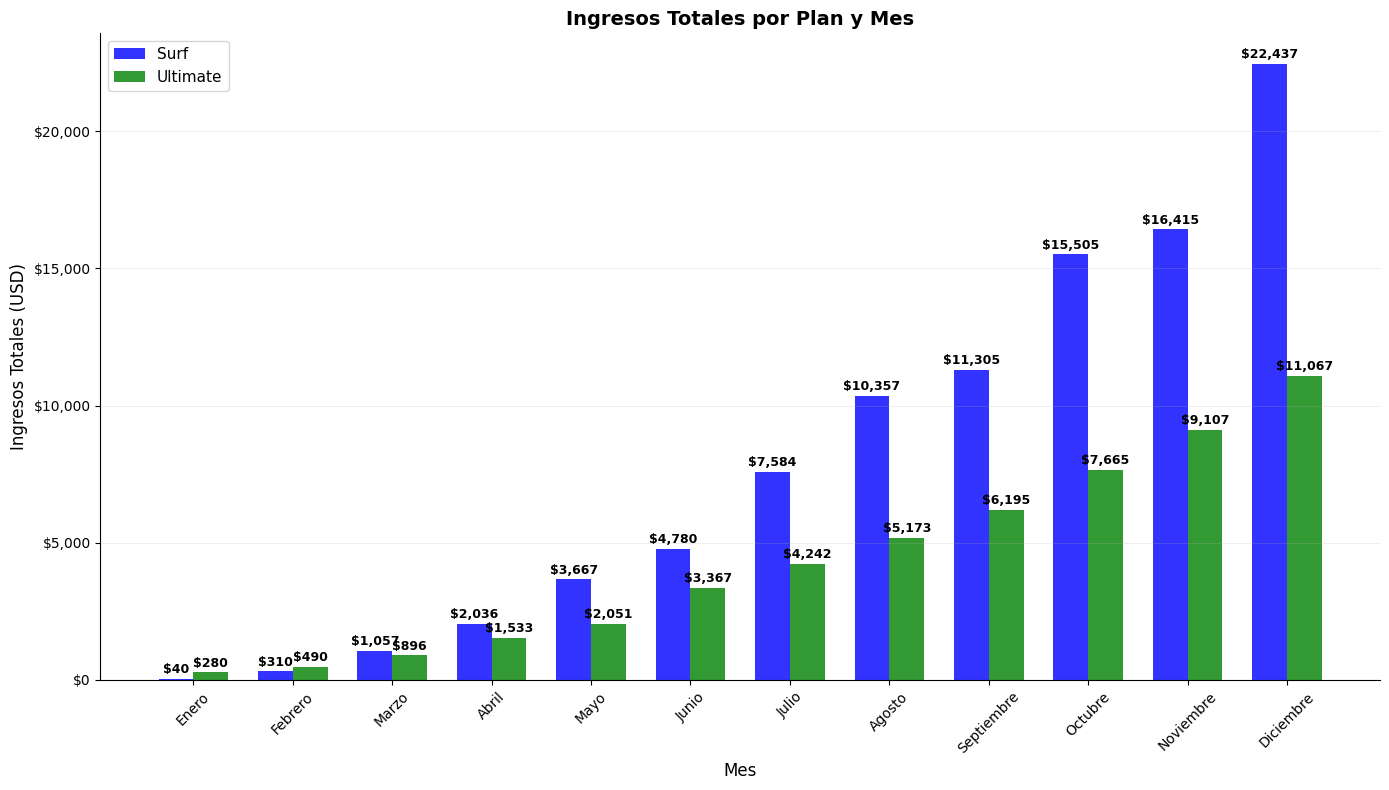

In [245]:
# Crear gráfico de ingresos totales por mes y plan
plt.figure(figsize=(14, 8))

# Datos para el gráfico
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

surf_ingresos = ingresos_pivot['surf'].values
ultimate_ingresos = ingresos_pivot['ultimate'].values

x = np.arange(len(nombres_meses))
width = 0.35

# Crear las barras
bars1 = plt.bar(x - width/2, surf_ingresos, width, label='Surf', color='blue', alpha=0.8)
bars2 = plt.bar(x + width/2, ultimate_ingresos, width, label='Ultimate', color='green', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ingresos Totales (USD)', fontsize=12)
plt.title('Ingresos Totales por Plan y Mes', fontsize=14, fontweight='bold')
plt.xticks(x, nombres_meses, rotation=45)
plt.legend(fontsize=11)

# Agregar valores en las barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'${height:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configuración del grid y formato
plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Formato de números en el eje Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [242]:
print("\nTABLA PIVOTE - CANTIDAD DE USUARIOS POR MES Y PLAN:")
usuarios_pivot


TABLA PIVOTE - CANTIDAD DE USUARIOS POR MES Y PLAN:


plan,surf,ultimate
month,,
1,2,4
2,9,7
3,23,12
4,50,21
5,77,29
6,97,47
7,121,59
8,162,71
9,194,86


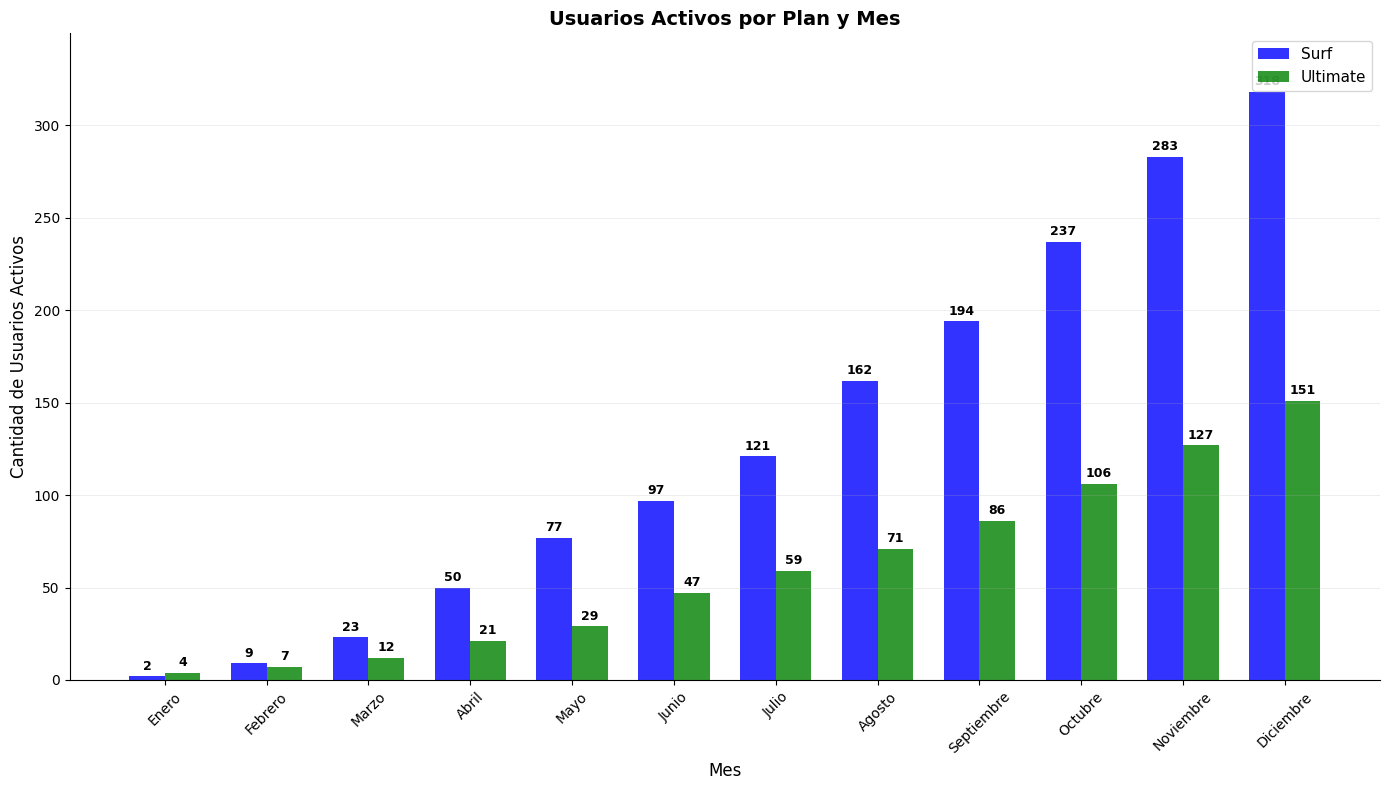

In [246]:
# Crear gráfico de usuarios activos por mes y plan
plt.figure(figsize=(14, 8))

# Datos para el gráfico
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

surf_usuarios = usuarios_pivot['surf'].values
ultimate_usuarios = usuarios_pivot['ultimate'].values

x = np.arange(len(nombres_meses))
width = 0.35

# Crear las barras
bars1 = plt.bar(x - width/2, surf_usuarios, width, label='Surf', color='blue', alpha=0.8)
bars2 = plt.bar(x + width/2, ultimate_usuarios, width, label='Ultimate', color='green', alpha=0.8)

# Personalizar el gráfico
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Cantidad de Usuarios Activos', fontsize=12)
plt.title('Usuarios Activos por Plan y Mes', fontsize=14, fontweight='bold')
plt.xticks(x, nombres_meses, rotation=45)
plt.legend(fontsize=11)

# Agregar valores en las barras
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Configuración del grid y formato
plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Formato de números en el eje Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}'))

# Ajustar el rango del eje Y para mejor visualización
plt.ylim(0, max(max(surf_usuarios), max(ultimate_usuarios)) * 1.1)

plt.tight_layout()
plt.show()

In [235]:
# Crear tabla resumen de ingresos totales por plan
revenue_summary = monthly_data.groupby('plan').agg({
    'monthly_revenue': ['sum', 'mean', 'count', 'std']
}).round(2)

# Aplanar columnas
revenue_summary.columns = ['total_revenue', 'avg_revenue_per_user', 'total_records', 'std_revenue']
revenue_summary = revenue_summary.reset_index()

print("\nResumen de ingresos por plan:")
revenue_summary


Resumen de ingresos por plan:


,plan,total_revenue,avg_revenue_per_user,total_records,std_revenue
0,surf,95491.18,60.71,1573,55.39
1,ultimate,52066.00,72.31,720,11.40


In [254]:
# Estadísticas de ingresos por plan (formato correcto)
print("ESTADÍSTICAS DE INGRESOS POR PLAN:")
print("\nPlan Surf:")
surf_ingresos = monthly_data[monthly_data['plan'] == 'surf']['monthly_revenue']
print(f"Mínimo: ${surf_ingresos.min():.2f}")
print(f"Máximo: ${surf_ingresos.max():.2f}")
print(f"Media: ${surf_ingresos.mean():.2f}")
print(f"Mediana: ${surf_ingresos.median():.2f}")
print(f"Desviación estándar: {surf_ingresos.std():.2f}")  
print(f"Varianza: {surf_ingresos.var():.2f}")            

print("\nPlan Ultimate:")
ultimate_ingresos = monthly_data[monthly_data['plan'] == 'ultimate']['monthly_revenue']
print(f"Mínimo: ${ultimate_ingresos.min():.2f}")
print(f"Máximo: ${ultimate_ingresos.max():.2f}")
print(f"Media: ${ultimate_ingresos.mean():.2f}")
print(f"Mediana: ${ultimate_ingresos.median():.2f}")
print(f"Desviación estándar: {ultimate_ingresos.std():.2f}")  
print(f"Varianza: {ultimate_ingresos.var():.2f}")            

ESTADÍSTICAS DE INGRESOS POR PLAN:

Plan Surf:
Mínimo: $20.00
Máximo: $590.37
Media: $60.71
Mediana: $40.36
Desviación estándar: 55.39
Varianza: 3067.84

Plan Ultimate:
Mínimo: $70.00
Máximo: $182.00
Media: $72.31
Mediana: $70.00
Desviación estándar: 11.40
Varianza: 129.85


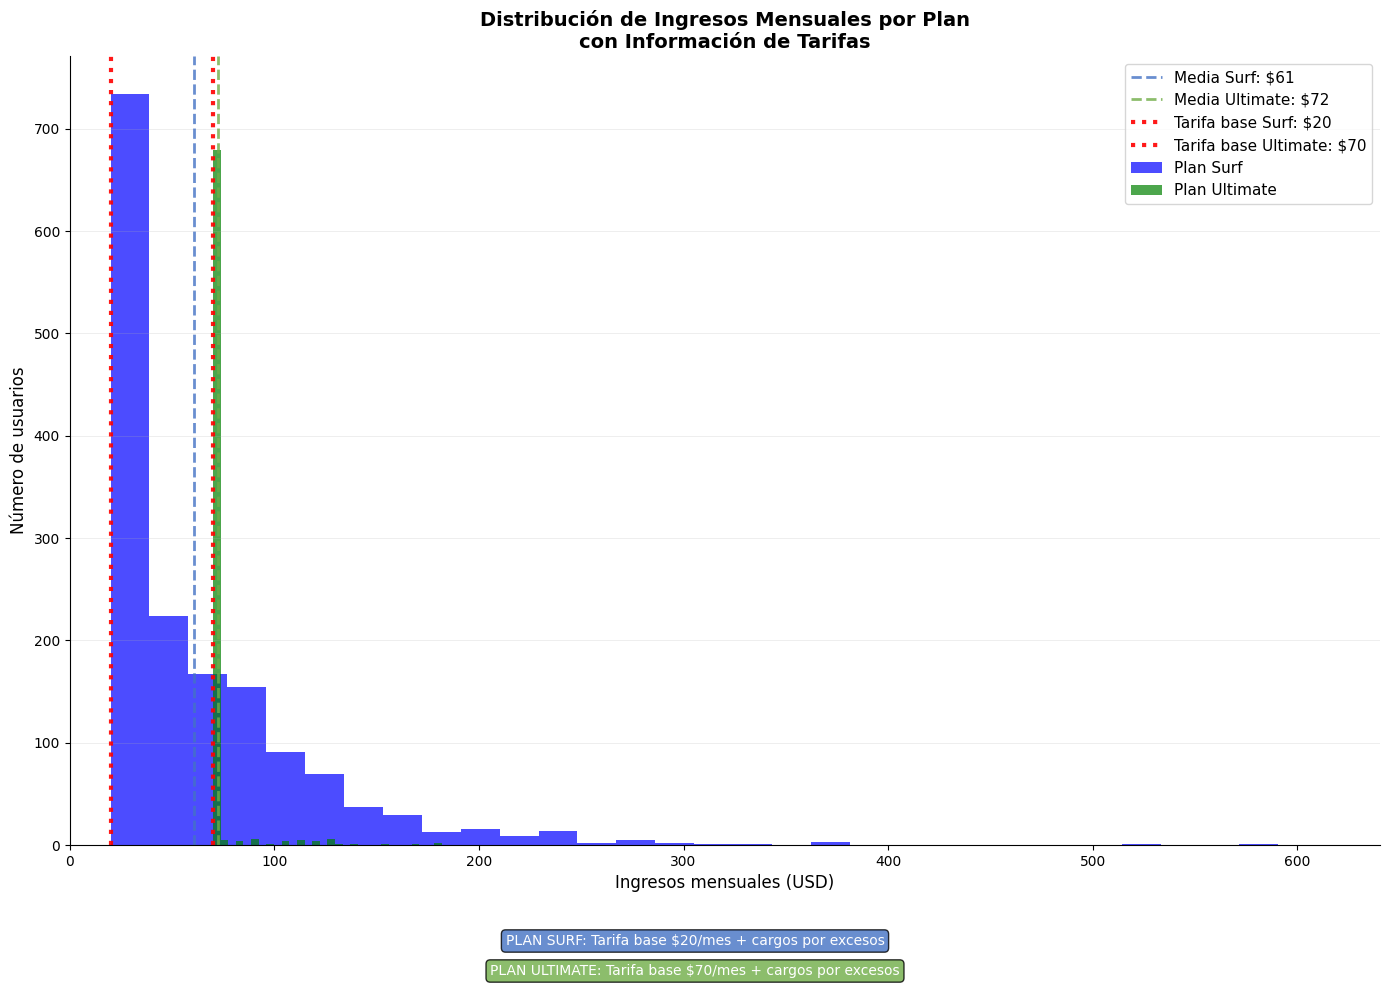

In [256]:
# Crear histograma para comparar distribución de ingresos por plan
plt.figure(figsize=(14, 10))

# Separar los datos de ingresos por plan
surf_ingresos = monthly_data[monthly_data['plan'] == 'surf']['monthly_revenue']
ultimate_ingresos = monthly_data[monthly_data['plan'] == 'ultimate']['monthly_revenue']

# Crear histograma
plt.hist(surf_ingresos, bins=30, alpha=0.7, label='Plan Surf', color='blue')
plt.hist(ultimate_ingresos, bins=30, alpha=0.7, label='Plan Ultimate', color='green')

# Etiquetas y título
plt.xlabel('Ingresos mensuales (USD)', fontsize=12)
plt.ylabel('Número de usuarios', fontsize=12)
plt.title('Distribución de Ingresos Mensuales por Plan\ncon Información de Tarifas', fontsize=14, fontweight='bold')

# Líneas verticales para las medias
plt.axvline(surf_ingresos.mean(), color='#4472C4', linestyle='--', alpha=0.8, linewidth=2,
           label=f'Media Surf: ${surf_ingresos.mean():.0f}')
plt.axvline(ultimate_ingresos.mean(), color='#70AD47', linestyle='--', alpha=0.8, linewidth=2,
           label=f'Media Ultimate: ${ultimate_ingresos.mean():.0f}')

# Líneas verticales para las tarifas base
plt.axvline(20, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Tarifa base Surf: $20')
plt.axvline(70, color='red', linestyle=':', linewidth=3, alpha=0.9,
           label='Tarifa base Ultimate: $70')

# Rango del eje X para mostrar toda la distribución
plt.xlim(0, max(surf_ingresos.max(), ultimate_ingresos.max()) + 50)

# Información de los planes
textstr1 = 'PLAN SURF: Tarifa base $20/mes + cargos por excesos'
textstr2 = 'PLAN ULTIMATE: Tarifa base $70/mes + cargos por excesos'

plt.figtext(0.5, 0.05, textstr1, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='#4472C4', alpha=0.8))
plt.figtext(0.5, 0.02, textstr2, ha='center', fontsize=10, color='white',
           bbox=dict(boxstyle='round', facecolor='#70AD47', alpha=0.8))

# Configuración del grid y formato
plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Leyenda
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Dar espacio para el texto inferior
plt.show()

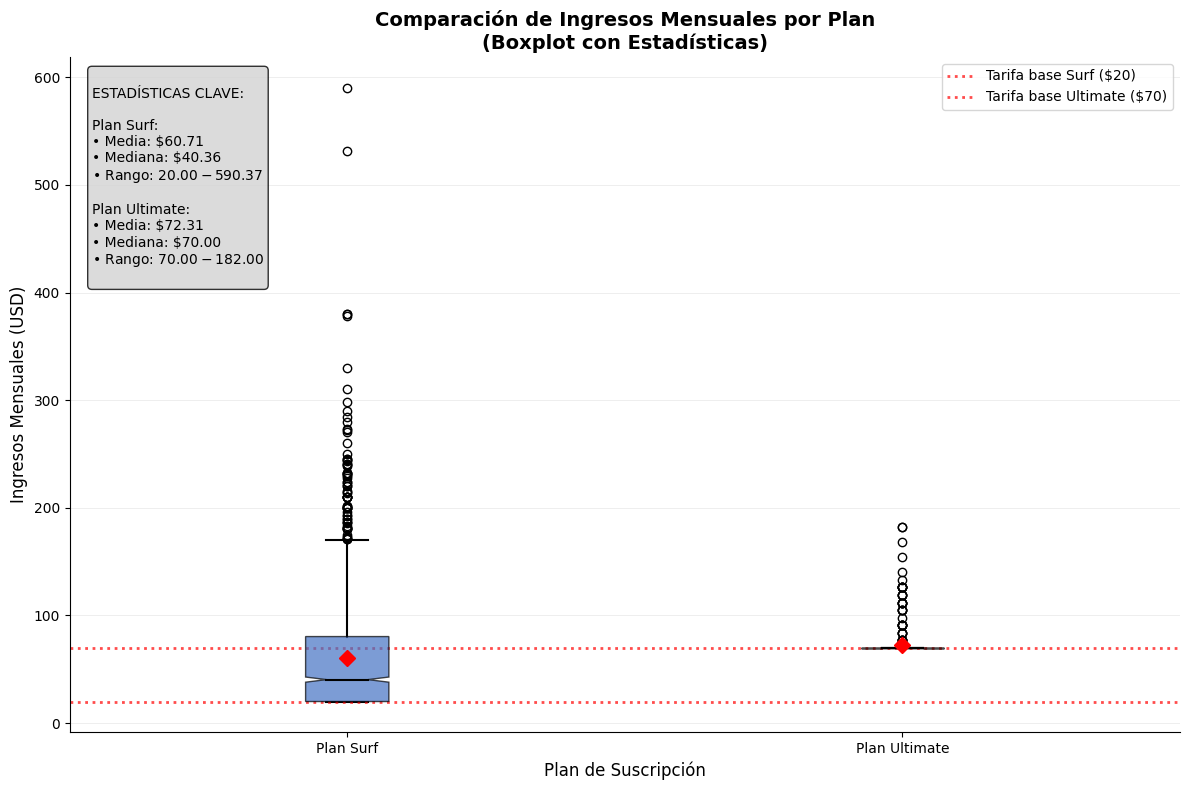

In [257]:
# Crear boxplot para comparar ingresos entre planes
plt.figure(figsize=(12, 8))

# Crear el boxplot
box_plot = plt.boxplot([surf_ingresos, ultimate_ingresos], 
                       labels=['Plan Surf', 'Plan Ultimate'],
                       patch_artist=True,
                       notch=True,
                       showmeans=True)

# Personalizar colores
colors = ['#4472C4', '#70AD47']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Personalizar otros elementos
for element in ['whiskers', 'fliers', 'medians', 'caps']:
    plt.setp(box_plot[element], color='black', linewidth=1.5)

# Personalizar las medias
plt.setp(box_plot['means'], marker='D', markerfacecolor='red', 
         markeredgecolor='red', markersize=8)

# Etiquetas y título
plt.ylabel('Ingresos Mensuales (USD)', fontsize=12)
plt.xlabel('Plan de Suscripción', fontsize=12)
plt.title('Comparación de Ingresos Mensuales por Plan\n(Boxplot con Estadísticas)', 
          fontsize=14, fontweight='bold')

# Agregar líneas de referencia para tarifas base
plt.axhline(y=20, color='red', linestyle=':', alpha=0.7, linewidth=2, 
           label='Tarifa base Surf ($20)')
plt.axhline(y=70, color='red', linestyle=':', alpha=0.7, linewidth=2, 
           label='Tarifa base Ultimate ($70)')

# Agregar estadísticas como texto
stats_text = f"""
ESTADÍSTICAS CLAVE:

Plan Surf:
• Media: ${surf_ingresos.mean():.2f}
• Mediana: ${surf_ingresos.median():.2f}
• Rango: ${surf_ingresos.min():.2f} - ${surf_ingresos.max():.2f}

Plan Ultimate:
• Media: ${ultimate_ingresos.mean():.2f}
• Mediana: ${ultimate_ingresos.median():.2f}
• Rango: ${ultimate_ingresos.min():.2f} - ${ultimate_ingresos.max():.2f}
"""

plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# Configuración del grid y formato
plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Leyenda
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

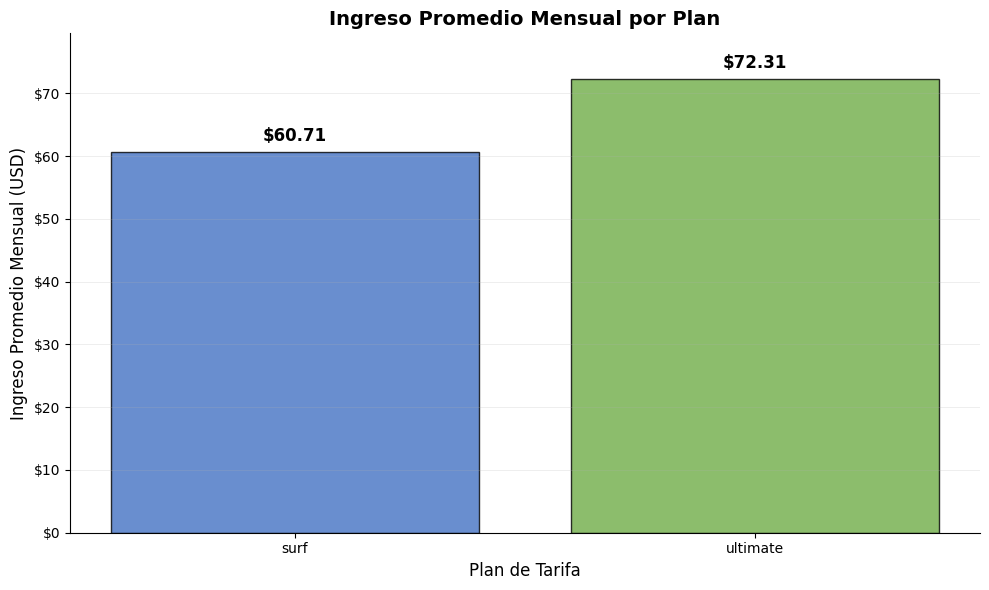

Ingreso promedio mensual por plan:
Surf: $60.71
Ultimate: $72.31


In [258]:
# Calcular el ingreso promedio mensual por plan
ingreso_promedio_por_plan = monthly_data.groupby('plan').agg({
    'monthly_revenue': 'mean'
}).reset_index()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))

# Crear las barras
bars = plt.bar(ingreso_promedio_por_plan['plan'], 
               ingreso_promedio_por_plan['monthly_revenue'],
               color=['#4472C4', '#70AD47'], 
               alpha=0.8,
               edgecolor='black',
               linewidth=1)

# Personalizar el gráfico
plt.xlabel('Plan de Tarifa', fontsize=12)
plt.ylabel('Ingreso Promedio Mensual (USD)', fontsize=12)
plt.title('Ingreso Promedio Mensual por Plan', fontsize=14, fontweight='bold')

# Agregar valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'${height:.2f}', ha='center', va='bottom', 
             fontsize=12, fontweight='bold')

# Configuración del grid y formato
plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Formato de números en el eje Y
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}'))

# Ajustar el rango del eje Y para mejor visualización
plt.ylim(0, max(ingreso_promedio_por_plan['monthly_revenue']) * 1.1)

plt.tight_layout()
plt.show()

# Mostrar los valores exactos
print("Ingreso promedio mensual por plan:")
for _, row in ingreso_promedio_por_plan.iterrows():
    print(f"{row['plan'].capitalize()}: ${row['monthly_revenue']:.2f}")

**Conclusiones sobre cómo difiere el ingreso entre los planes Surf y Ultimate**

El análisis de los ingresos revela diferencias claras entre los planes Surf y Ultimate, tanto en la magnitud de los ingresos como en su comportamiento general.

En primer lugar, el plan Ultimate genera un ingreso promedio mensual mayor por usuario (72.31) en comparación con el plan Surf, cuyo ingreso promedio es de 60.71. Esto se debe a que Ultimate tiene una tarifa mensual fija elevada (70), lo que hace que la mayoría de los usuarios paguen una cantidad estable cercana a ese valor. La mediana de Ultimate (70) confirma esta estabilidad.

Por el contrario, el plan Surf presenta una mayor variabilidad en los ingresos. Aunque su pago mensual básico es menor (20), muchos usuarios superan los límites de minutos, SMS o datos, lo que incrementa considerablemente sus cargos mensuales. Esto se refleja en un ingreso máximo muy superior (590.37) y en una desviación estándar elevada (55.39), indicando que los usuarios de Surf tienen un comportamiento mucho más heterogéneo. La mediana relativamente baja (40.36) muestra que la mayoría paga poco, pero un grupo pequeño de usuarios genera ingresos extraordinariamente altos debido a excesos de uso.

En resumen:

- Ultimate es un plan más estable y predecible, con ingresos concentrados alrededor de su cuota mensual.

- Surf es más variable y con potencial de ingresos altos, gracias a los cargos adicionales generados por algunos usuarios intensivos.

- Aunque Ultimate aporta más ingreso promedio por usuario, Surf puede generar ingresos totales altos en usuarios que sobrepasan los límites del plan.

Estas diferencias reflejan dos modelos de ingresos distintos: Ultimate aporta estabilidad, mientras que Surf aporta variabilidad y picos de ingresos, lo cual es relevante para decisiones comerciales y de publicidad.


## Prueba las hipótesis estadísticas

A continuación se realizará una prueba estadística para determinar si existe una diferencia significativa en los ingresos promedio generados por los usuarios de los planes Surf y Ultimate.

**Tipo de hipótesis seleccionada: Hipótesis de dos colas (bilateral)**

Para la hipótesis que compara los ingresos promedio entre los planes Surf y Ultimate, se seleccionó una prueba de hipótesis de dos colas por las siguientes razones:

- Naturaleza de la pregunta de investigación: No teníamos una expectativa previa sobre cuál plan generaría mayores ingresos. La pregunta era simplemente si existe una diferencia significativa entre los ingresos de ambos planes, sin importar la dirección de esa diferencia.
  
- Formulación de hipótesis apropiada: 
  - H₀ (Hipótesis nula): Los ingresos promedio de ambos planes son iguales
  - H₁ (Hipótesis alternativa): Los ingresos promedio de ambos planes son diferentes
La hipótesis alternativa utiliza la palabra "diferentes" en lugar de "mayor que" o "menor que", lo cual indica claramente que estamos interesados en detectar diferencias en cualquier dirección.

- Distribución del área crítica: En una prueba de dos colas, el nivel de significancia (α = 0.05) se divide igualmente entre ambos extremos de la distribución (2.5% en cada cola). Esto significa que rechazaremos la hipótesis nula si el valor observado es significativamente mayor O significativamente menor que el valor esperado bajo H₀.
  
- Interpretación práctica: Desde la perspectiva del negocio, es importante detectar si cualquiera de los dos planes genera significativamente más ingresos que el otro, ya que esta información es valiosa para las decisiones de marketing y estrategia comercial, independientemente de cuál plan resulte superior.

- Prueba estadística utilizada: t-test para muestras independientes (scipy.stats.ttest_ind), que es apropiada para comparar las medias de dos grupos independientes cuando queremos detectar diferencias en cualquier dirección.

Esta elección metodológica nos permite obtener una evaluación completa e imparcial de las diferencias entre los planes, proporcionando información valiosa para la toma de decisiones comerciales.

In [269]:
# PRUEBA DE HIPÓTESIS 1: Comparación de ingresos entre planes
print("PRUEBA DE HIPÓTESIS 1: Comparación de ingresos entre planes")
print("=" * 60)

# Formular hipótesis
print("H0 (Hipótesis nula): Los ingresos promedio de ambos planes son iguales")
print("H1 (Hipótesis alternativa): Los ingresos promedio de ambos planes son diferentes")
print("Nivel de significancia (α): 0.05")
print("Prueba estadística: t-test para muestras independientes (dos colas)")
print()

# Separar los datos de ingresos por plan
surf_revenues = monthly_data[monthly_data['plan'] == 'surf']['monthly_revenue']
ultimate_revenues = monthly_data[monthly_data['plan'] == 'ultimate']['monthly_revenue']

# Realizar la prueba t para muestras independientes
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(surf_revenues, ultimate_revenues)

print(f"\nRESULTADOS DE LA PRUEBA:")
print(f"Estadístico t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia: 0.05")

# Interpretación de resultados
if p_value < 0.05:
    print("\nCONCLUSIÓN:")
    print(f"Con p-value = {p_value:.6f} < 0.05, RECHAZAMOS la hipótesis nula.")
    print("Existe evidencia estadísticamente significativa de que los ingresos promedio")
    print("entre los planes Surf y Ultimate son DIFERENTES.")
else:
    print("\nCONCLUSIÓN:")
    print(f"Con p-value = {p_value:.6f} >= 0.05, NO RECHAZAMOS la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar que los ingresos promedio")
    print("entre los planes son diferentes.")

# Estadísticas descriptivas para contexto
print(f"\nESTADÍSTICAS DESCRIPTIVAS:")
print(f"Plan Surf - Media: ${surf_revenues.mean():.2f}, N = {len(surf_revenues)}")
print(f"Plan Ultimate - Media: ${ultimate_revenues.mean():.2f}, N = {len(ultimate_revenues)}")
print(f"Diferencia de medias: ${ultimate_revenues.mean() - surf_revenues.mean():.2f}")

PRUEBA DE HIPÓTESIS 1: Comparación de ingresos entre planes
H0 (Hipótesis nula): Los ingresos promedio de ambos planes son iguales
H1 (Hipótesis alternativa): Los ingresos promedio de ambos planes son diferentes
Nivel de significancia (α): 0.05
Prueba estadística: t-test para muestras independientes (dos colas)


RESULTADOS DE LA PRUEBA:
Estadístico t: -5.5689
Valor p: 0.000000
Nivel de significancia: 0.05

CONCLUSIÓN:
Con p-value = 0.000000 < 0.05, RECHAZAMOS la hipótesis nula.
Existe evidencia estadísticamente significativa de que los ingresos promedio
entre los planes Surf y Ultimate son DIFERENTES.

ESTADÍSTICAS DESCRIPTIVAS:
Plan Surf - Media: $60.71, N = 1573
Plan Ultimate - Media: $72.31, N = 720
Diferencia de medias: $11.61


A continuación se realizará una prueba estadística para determinar si existe una diferencia significativa en los ingresos promedio generados por los usuarios de la región NY-NJ comparado con los usuarios de otras regiones.

**Tipo de hipótesis seleccionada: Hipótesis de dos colas (bilateral)**

Para la hipótesis que compara los ingresos promedio entre usuarios de NY-NJ y otras regiones, se seleccionó una prueba de hipótesis de dos colas por las siguientes razones:

- Naturaleza de la pregunta de investigación: No teníamos una expectativa previa sobre qué región generaría mayores ingresos. La pregunta era simplemente si existe una diferencia significativa entre los ingresos de usuarios de NY-NJ y otras regiones, sin importar la dirección de esa diferencia.

- Formulación de hipótesis apropiada:

  - H₀ (Hipótesis nula): Los ingresos promedio de usuarios NY-NJ son iguales a los de otras regiones

  - H₁ (Hipótesis alternativa): Los ingresos promedio de usuarios NY-NJ son diferentes a los de otras regiones. La hipótesis alternativa utiliza la palabra "diferentes" en lugar de "mayor que" o "menor que", lo cual indica claramente que estamos interesados en detectar diferencias en cualquier dirección.

- Distribución del área crítica: En una prueba de dos colas, el nivel de significancia (α = 0.05) se divide igualmente entre ambos extremos de la distribución (2.5% en cada cola). Esto significa que rechazaremos la hipótesis nula si el valor observado es significativamente mayor O significativamente menor que el valor esperado bajo H₀.

- Interpretación práctica: Desde la perspectiva del negocio, es importante detectar si cualquiera de las regiones genera significativamente más ingresos que la otra, ya que esta información es valiosa para las decisiones de marketing y estrategia comercial regional, independientemente de cuál región resulte superior.

- Prueba estadística utilizada: t-test para muestras independientes (scipy.stats.ttest_ind), que es apropiada para comparar las medias de dos grupos independientes cuando queremos detectar diferencias en cualquier dirección.

Esta elección metodológica nos permite obtener una evaluación completa e imparcial de las diferencias entre las regiones, proporcionando información valiosa para la toma de decisiones comerciales.

In [272]:
# Verificar las ciudades únicas para identificar NY-NJ
print("Ciudades únicas en el dataset:")
print(users['city'].unique())

Ciudades únicas en el dataset:
['Atlanta-Sandy Springs-Roswell, GA MSA' 'Seattle-Tacoma-Bellevue, WA MSA'
 'Las Vegas-Henderson-Paradise, NV MSA' 'Tulsa, OK MSA'
 'Dallas-Fort Worth-Arlington, TX MSA'
 'San Francisco-Oakland-Berkeley, CA MSA' 'Grand Rapids-Kentwood, MI MSA'
 'Orlando-Kissimmee-Sanford, FL MSA'
 'San Jose-Sunnyvale-Santa Clara, CA MSA' 'Cleveland-Elyria, OH MSA'
 'Chicago-Naperville-Elgin, IL-IN-WI MSA' 'Knoxville, TN MSA'
 'New York-Newark-Jersey City, NY-NJ-PA MSA' 'Pittsburgh, PA MSA'
 'Fresno, CA MSA' 'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA'
 'Indianapolis-Carmel-Anderson, IN MSA' 'Jacksonville, FL MSA'
 'Los Angeles-Long Beach-Anaheim, CA MSA'
 'Omaha-Council Bluffs, NE-IA MSA'
 'Houston-The Woodlands-Sugar Land, TX MSA'
 'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA'
 'Tampa-St. Petersburg-Clearwater, FL MSA' 'Birmingham-Hoover, AL MSA'
 'Oklahoma City, OK MSA' 'Charlotte-Concord-Gastonia, NC-SC MSA'
 'Denver-Aurora-Lakewood, CO MSA'
 'Nashville-David

In [273]:
# PRUEBA DE HIPÓTESIS 2: Comparación de ingresos entre regiones
print("PRUEBA DE HIPÓTESIS 2: Comparación de ingresos entre regiones NY-NJ vs otras regiones")
print("-" * 60)

# Formular hipótesis
print("H0 (Hipótesis nula): Los ingresos promedio de usuarios NY-NJ son iguales a los de otras regiones")
print("H1 (Hipótesis alternativa): Los ingresos promedio de usuarios NY-NJ son diferentes a los de otras regiones")
print("Nivel de significancia (α): 0.05")
print("Prueba estadística: t-test para muestras independientes (dos colas)")
print()

# Separar los datos de ingresos por región
# Primero identificar usuarios de NY-NJ
ny_nj_users = users[users['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA']['user_id']
ny_nj_revenues = monthly_data[monthly_data['user_id'].isin(ny_nj_users)]['monthly_revenue']
other_regions_revenues = monthly_data[~monthly_data['user_id'].isin(ny_nj_users)]['monthly_revenue']

# Realizar la prueba t para muestras independientes
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(ny_nj_revenues, other_regions_revenues)

print(f"\nRESULTADOS DE LA PRUEBA:")
print(f"Estadístico t: {t_statistic:.4f}")
print(f"Valor p: {p_value:.6f}")
print(f"Nivel de significancia: 0.05")

# Interpretación de resultados
if p_value < 0.05:
    print("\nCONCLUSIÓN:")
    print(f"Con p-value = {p_value:.6f} < 0.05, RECHAZAMOS la hipótesis nula.")
    print("Existe evidencia estadísticamente significativa de que los ingresos promedio")
    print("entre usuarios de NY-NJ y otras regiones son DIFERENTES.")
else:
    print("\nCONCLUSIÓN:")
    print(f"Con p-value = {p_value:.6f} >= 0.05, NO RECHAZAMOS la hipótesis nula.")
    print("No hay evidencia suficiente para afirmar que los ingresos promedio")
    print("entre las regiones son diferentes.")

# Estadísticas descriptivas para contexto
print(f"\nESTADÍSTICAS DESCRIPTIVAS:")
print(f"Región NY-NJ - Media: ${ny_nj_revenues.mean():.2f}, N = {len(ny_nj_revenues)}")
print(f"Otras regiones - Media: ${other_regions_revenues.mean():.2f}, N = {len(other_regions_revenues)}")
print(f"Diferencia de medias: ${ny_nj_revenues.mean() - other_regions_revenues.mean():.2f}")

PRUEBA DE HIPÓTESIS 2: Comparación de ingresos entre regiones NY-NJ vs otras regiones
------------------------------------------------------------
H0 (Hipótesis nula): Los ingresos promedio de usuarios NY-NJ son iguales a los de otras regiones
H1 (Hipótesis alternativa): Los ingresos promedio de usuarios NY-NJ son diferentes a los de otras regiones
Nivel de significancia (α): 0.05
Prueba estadística: t-test para muestras independientes (dos colas)


RESULTADOS DE LA PRUEBA:
Estadístico t: -2.0194
Valor p: 0.043557
Nivel de significancia: 0.05

CONCLUSIÓN:
Con p-value = 0.043557 < 0.05, RECHAZAMOS la hipótesis nula.
Existe evidencia estadísticamente significativa de que los ingresos promedio
entre usuarios de NY-NJ y otras regiones son DIFERENTES.

ESTADÍSTICAS DESCRIPTIVAS:
Región NY-NJ - Media: $59.92, N = 377
Otras regiones - Media: $65.22, N = 1916
Diferencia de medias: $-5.30


# CONCLUSIONES DEL PROYECTO DE ANÁLISIS DE MEGALINE

1. Decisiones de Preparación de Datos
- Conversión de tipos de datos: Se convirtieron las fechas a formato datetime y se aseguró que los valores numéricos estuvieran en el tipo correcto para facilitar los cálculos posteriores.
- Tratamiento de datos faltantes: Se identificaron y manejaron los valores nulos, especialmente en la columna churn_date, donde los valores ausentes indicaban usuarios activos.
- Aplicación de reglas de negocio: Se implementaron correctamente las reglas de redondeo específicas de Megaline:
Llamadas: redondeo hacia arriba por llamada individual
Datos de internet: redondeo hacia arriba del total mensual (MB a GB)

2. Decisiones de Cálculo de Ingresos
- Metodología de cálculo: Se desarrolló una función sistemática que calcula los ingresos considerando:
  - Cuota base mensual del plan
  - Cargos por exceso de minutos, SMS y datos
  - Diferencias en tarifas entre planes Surf y Ultimate
- Agregación temporal: Se agruparon los datos por usuario y mes para obtener métricas mensuales consistentes.

3. Decisiones de Análisis Estadístico
- Métricas descriptivas: Se calcularon valores mínimos, máximos, media, varianza y desviación estándar para caracterizar el comportamiento de uso por plan.
- Visualizaciones: Se utilizaron histogramas para identificar la distribución de los datos y detectar patrones de comportamiento diferenciados entre planes.

4. Decisiones de Pruebas de Hipótesis
##### Hipótesis 1: Comparación entre planes Surf y Ultimate
- Tipo de prueba: t-test bilateral para muestras independientes
- Justificación: No había expectativa previa sobre cuál plan generaría mayores ingresos
- Nivel de significancia: α = 0.05 (estándar en análisis de negocio)

##### Hipótesis 2: Comparación regional NY-NJ vs otras regiones
- Tipo de prueba: t-test bilateral para muestras independientes
- Justificación: No había expectativa previa sobre diferencias regionales en ingresos
- Segmentación: Se identificó específicamente la región "New York-Newark-Jersey City, NY-NJ-PA MSA"

5. Decisiones Metodológicas Clave
- Selección de pruebas bilaterales: Se eligieron pruebas de dos colas porque el objetivo era detectar diferencias en cualquier dirección, no probar superioridad específica.
- Uso de scipy.stats.ttest_ind: Se seleccionó esta función por ser apropiada para comparar medias de dos grupos independientes con distribuciones aproximadamente normales.
- Interpretación conservadora: Se adoptó un enfoque conservador en la interpretación, rechazando H₀ solo cuando p < 0.05.

# Conclusiones de Negocio
1. Volumen de Usuarios
- Plan Surf: 339 usuarios (67.8% del total)
- Plan Ultimate: 161 usuarios (32.2% del total)
- Proporción: 2.1 usuarios de Surf por cada usuario de Ultimate

2. Ingresos Totales por Plan
- Plan Surf: USD 95,491.18 (total)
- Plan Ultimate: USD 52,066.00 (total)

3. Estadísticas Descriptivas

- Plan Surf:

  - Ingreso promedio mensual: USD 60.71
  - Mediana: USD40.36
  - Rango: USD20.00 - USD 590.37
  - Desviación estándar: USD 55.39
  - Total de registros: 1,573


- Plan Ultimate:

  - Ingreso promedio mensual: USD 72.31
  - Mediana: USD 70.00
  - Rango: USD 70.00 - USD 182.00
  - Desviación estándar: USD 11.40
  - Total de registros: 720

4. Conclusión

El plan Surf genera más ingresos totales (USD 95.491 vs USD 52.066), a pesar de tener menor ingreso promedio por usuario (USD 60.71 vs USD 72.31).

##### Razones del éxito del plan Surf:

- Mayor base de usuarios: el doble de clientes compensa el menor ingreso individual.

- Ingresos por excesos: los usuarios frecuentemente superan los límites, generando cargos adicionales significativos.

- Accesibilidad: el precio base de USD 20 atrae más usuarios que el de USD 70.

##### Razones por las que Ultimate genera menos ingresos totales:

- Menor adopción: solo 32.2% de los usuarios eligen este plan.

- Límites subutilizados: los usuarios no aprovechan completamente los beneficios incluidos.

- Menor generación de excesos: pocos usuarios superan los límites generosos.

## Conclusión y recomendación estratégica para el departamento comercial:

Basado en el análisis de los datos de 500 clientes de Megaline durante 2018, **el plan Surf genera significativamente más ingresos totales que el plan Ultimate**, siendo la opción más rentable para maximizar los ingresos de la empresa.

**Hallazgos clave:**
- Plan Surf: Mayor volumen de usuarios y ingresos totales superiores
- Plan Ultimate: Menor base de usuarios pero mayor ingreso promedio por usuario
- Impacto financiero: El plan Surf representa la principal fuente de ingresos de la empresa
  
**Recomendación para la asignación del presupuesto publicitario:**

Estrategia 70-30:

- 70% del presupuesto al plan Surf: Maximizar la captación de usuarios del segmento más rentable
- 30% del presupuesto al plan Ultimate: Mantener diversificación y captar usuarios de alto valor

Estrategia complementaria: Implementar campañas de migración selectiva para usuarios Surf de muy alto consumo hacia Ultimate, optimizando así el valor por cliente sin perder la base principal de ingresos.